# Revision: Spin Contamination Distribution and Outlier Association

Objective: report the observed TS `<S**2>` distribution and test whether unusually high values are enriched among BEP residual outliers.

Done means this notebook:

- parses or loads final TS `<S**2>` values for the released `Data/TS/Borane_all.csv` set;
- recomputes the global BEP residuals from `DeltaG_rxn` and `DeltaG_act`;
- labels outliers using a transparent residual threshold;
- exports compact tables and manuscript-ready figures.

## Plan

1. Load the released TS table and construct the Gaussian log identifier.
2. Parse final TS logs from the historical raw Gaussian directory, caching the result for reviewer reruns without the raw workspace.
3. Summarize the observed `<S**2>` values directly, with 0.75 as the doublet reference.
4. Fit the global BEP line, label residual outliers, and compare the observed `<S**2>` distributions.
5. Save figures and summary CSV files.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Data" / "TS" / "Borane_all.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing Data/TS/Borane_all.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from DFTStructureGenerator.thermochemistry import database_path, load_reaction_dataset

# Thermochemistry switch: QHARM is the revised default.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM, PROJECT_ROOT)
BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
DATA_DIR = PROJECT_ROOT / "Data"
TS_CSV = DATA_DIR / "TS" / "Borane_all.csv"
OUTPUT_DIR = PROJECT_ROOT / "output" / "jupyter-notebook"
FIGURE_DIR = PROJECT_ROOT / "Figure"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPIN_CACHE_CSV = OUTPUT_DIR / "spin_contamination_ts.csv"
ANALYSIS_CSV = OUTPUT_DIR / "spin_contamination_outlier_association.csv"
SUMMARY_CSV = OUTPUT_DIR / "spin_contamination_outlier_summary.csv"

RAW_TS_LOG_DIR = Path("E:/work/B_Cl_Nu/Sum/TS_needIRC")
SPIN_LOG_LOCATOR_VERSION = "TS_needIRC_base_then_conf_v1"
REBUILD_SPIN_CACHE = False
S2_REFERENCE_DOUBLET = 0.75
S2_CONTAMINATION_CUTOFF = 0.05
S2_HIGH_VALUE_CUTOFF = S2_REFERENCE_DOUBLET + S2_CONTAMINATION_CUTOFF
OUTLIER_SIGMA = 2.0
RANDOM_SEED = 20260626

plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"TS CSV: {TS_CSV}")
print(f"Spin cache: {SPIN_CACHE_CSV}")
print(f"Raw TS log directory exists: {RAW_TS_LOG_DIR.exists()} ({RAW_TS_LOG_DIR})")
print(f"Log locator version: {SPIN_LOG_LOCATOR_VERSION}")

Project root: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database
TS CSV: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\TS\Borane_all.csv
Spin cache: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\spin_contamination_ts.csv
Raw TS log directory exists: True (E:\work\B_Cl_Nu\Sum\TS_needIRC)
Log locator version: TS_needIRC_base_then_conf_v1


## 1. Load Final TS Table

`3_Build_DataBase.ipynb` locates the TS Gaussian logs in `E:/work/B_Cl_Nu/Sum/TS_needIRC`.
For each TS row it first tries the no-conformer filename:

`B_{B_Index:05d}_Nu_{N_Index:05d}_Cl_{Cl_Index:05d}.log`

and then falls back to the conformer-specific filename:

`B_{B_Index:05d}_Nu_{N_Index:05d}_Cl_{Cl_Index:05d}_{conf_idxs_ts:04d}.log`

This notebook follows the same lookup order and keeps the conformer-specific identifier as the stable merge key.

In [2]:
def make_ts_identifier(df: pd.DataFrame) -> pd.Series:
    required = ["B_Index", "N_Index", "Cl_Index", "conf_idxs_ts"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Missing identifier columns: {missing}")
    return (
        "B_" + df["B_Index"].astype(int).astype(str).str.zfill(5)
        + "_Nu_" + df["N_Index"].astype(int).astype(str).str.zfill(5)
        + "_Cl_" + df["Cl_Index"].astype(int).astype(str).str.zfill(5)
        + "_" + df["conf_idxs_ts"].astype(int).astype(str).str.zfill(4)
    )


reaction_df = load_reaction_dataset(TS_CSV, use_qharm=USE_QHARM, db_path=DB_PATH)
reaction_df["identifier"] = make_ts_identifier(reaction_df)

if reaction_df["identifier"].duplicated().any():
    duplicated = reaction_df.loc[reaction_df["identifier"].duplicated(keep=False), "identifier"]
    raise ValueError(f"Duplicated TS identifiers detected, e.g. {duplicated.iloc[0]}")

print(f"Final TS reactions: {len(reaction_df):,}")
display(reaction_df[["identifier", "B_Index", "N_Index", "Cl_Index", "conf_idxs_ts", REACTION_ENERGY_COLUMN, BARRIER_COLUMN]].head())

Final TS reactions: 8,980


,identifier,B_Index,N_Index,Cl_Index,conf_idxs_ts,deltaG_qharm(kcal/mol),deltaGa_qharm(kcal/mol)
0,B_00388_Nu_00000_Cl_00500_0012,388,0,500,12,-31.954293,14.545776
1,B_00388_Nu_00001_Cl_00466_0013,388,1,466,13,-43.522449,9.404659
2,B_00388_Nu_00001_Cl_00474_0010,388,1,474,10,-25.620507,8.268203
3,B_00388_Nu_00001_Cl_00475_0002,388,1,475,2,-29.443907,11.353407
4,B_00388_Nu_00001_Cl_00476_0000,388,1,476,0,-40.008991,12.129193


## 2. Parse Or Load TS `<S**2>` Values

Gaussian reports the expected spin for these doublet TS calculations around `<S**2> = 0.75`.
This parser records both the value before annihilation and the value after annihilation when available.
The figures and reported ranges below use the observed `<S**2>` values directly; 0.75 is shown only as the ideal doublet reference.

In [3]:
FLOAT_RE = r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?"
S2_RE = re.compile(r"<S\*\*2>\s*=\s*(%s)" % FLOAT_RE)
ANNIHILATION_RE = re.compile(
    r"S\*\*2\s+before\s+annihilation\s+(%s),?\s+after\s+(%s)" % (FLOAT_RE, FLOAT_RE)
)
MULTIPLICITY_RE = re.compile(r"Charge\s*=\s*([-+]?\d+)\s+Multiplicity\s*=\s*(\d+)")


def expected_s2_from_multiplicity(multiplicity: float) -> float:
    if pd.isna(multiplicity):
        return np.nan
    spin = (float(multiplicity) - 1.0) / 2.0
    return spin * (spin + 1.0)


def parse_spin_from_log(path: Path) -> dict:
    s2_last = np.nan
    s2_before = np.nan
    s2_after = np.nan
    charge = np.nan
    multiplicity = np.nan
    normal_termination = False

    with path.open("rt", errors="ignore") as handle:
        for line in handle:
            s2_match = S2_RE.search(line)
            if s2_match:
                s2_last = float(s2_match.group(1))

            annihilation_match = ANNIHILATION_RE.search(line)
            if annihilation_match:
                s2_before = float(annihilation_match.group(1))
                s2_after = float(annihilation_match.group(2))

            multiplicity_match = MULTIPLICITY_RE.search(line)
            if multiplicity_match:
                charge = int(multiplicity_match.group(1))
                multiplicity = int(multiplicity_match.group(2))

            if "Normal termination of Gaussian" in line:
                normal_termination = True

    if np.isnan(s2_before):
        s2_before = s2_last
    s2_final = s2_after if not np.isnan(s2_after) else s2_before
    expected_s2 = expected_s2_from_multiplicity(multiplicity)

    return {
        "log_found": True,
        "log_path": str(path),
        "normal_termination": normal_termination,
        "charge": charge,
        "multiplicity": multiplicity,
        "expected_s2": expected_s2,
        "s2_before_annihilation": s2_before,
        "s2_after_annihilation": s2_after,
        "s2_final": s2_final,
        "spin_contamination_before": s2_before - expected_s2,
        "spin_contamination_after": s2_final - expected_s2,
    }


def locate_ts_log(row: pd.Series, log_dir: Path) -> tuple[Path | None, str]:
    base_stem = f"B_{int(row['B_Index']):05}_Nu_{int(row['N_Index']):05}_Cl_{int(row['Cl_Index']):05}"
    conf_stem = f"{base_stem}_{int(row['conf_idxs_ts']):04}"

    for variant, stem in [("base_without_conf", base_stem), ("conf_specific", conf_stem)]:
        path = log_dir / f"{stem}.log"
        if path.exists():
            return path, variant
    return None, "missing"


def build_spin_cache(reaction_table: pd.DataFrame, log_dir: Path) -> pd.DataFrame:
    if not log_dir.exists():
        raise FileNotFoundError(
            f"Raw TS log directory not found: {log_dir}. "
            f"Provide {SPIN_CACHE_CSV} or update RAW_TS_LOG_DIR."
        )

    rows = []
    t0 = time.time()
    for i, row in reaction_table[["identifier", "B_Index", "N_Index", "Cl_Index", "conf_idxs_ts"]].iterrows():
        identifier = row["identifier"]
        log_path, log_name_variant = locate_ts_log(row, log_dir)
        parsed = {
            "identifier": identifier,
            "B_Index": int(row["B_Index"]),
            "N_Index": int(row["N_Index"]),
            "Cl_Index": int(row["Cl_Index"]),
            "conf_idxs_ts": int(row["conf_idxs_ts"]),
            "log_source": SPIN_LOG_LOCATOR_VERSION,
            "log_name_variant": log_name_variant,
        }
        if log_path is not None:
            parsed.update(parse_spin_from_log(log_path))
        else:
            parsed.update({
                "log_found": False,
                "log_path": str(log_dir / f"{identifier}.log"),
                "normal_termination": False,
                "charge": np.nan,
                "multiplicity": np.nan,
                "expected_s2": np.nan,
                "s2_before_annihilation": np.nan,
                "s2_after_annihilation": np.nan,
                "s2_final": np.nan,
                "spin_contamination_before": np.nan,
                "spin_contamination_after": np.nan,
            })
        rows.append(parsed)

        if (len(rows) % 1000) == 0:
            print(f"Parsed {len(rows):,}/{len(reaction_table):,} logs in {time.time() - t0:.1f} s")

    return pd.DataFrame(rows)


cache_is_compatible = False
if SPIN_CACHE_CSV.exists() and not REBUILD_SPIN_CACHE:
    cached_cols = set(pd.read_csv(SPIN_CACHE_CSV, nrows=0).columns)
    cache_is_compatible = {"log_source", "log_name_variant"}.issubset(cached_cols)
    if cache_is_compatible:
        cache_sources = pd.read_csv(SPIN_CACHE_CSV, usecols=["log_source"])["log_source"].dropna().unique()
        cache_is_compatible = len(cache_sources) == 1 and cache_sources[0] == SPIN_LOG_LOCATOR_VERSION

if SPIN_CACHE_CSV.exists() and not REBUILD_SPIN_CACHE and cache_is_compatible:
    spin_df = pd.read_csv(SPIN_CACHE_CSV)
    print(f"Loaded spin cache: {SPIN_CACHE_CSV}")
else:
    if SPIN_CACHE_CSV.exists():
        print("Existing spin cache is missing the current locator metadata; rebuilding.")
    spin_df = build_spin_cache(reaction_df, RAW_TS_LOG_DIR)
    spin_df.to_csv(SPIN_CACHE_CSV, index=False)
    print(f"Wrote spin cache: {SPIN_CACHE_CSV}")

coverage = spin_df["log_found"].mean()
normal_rate = spin_df.loc[spin_df["log_found"], "normal_termination"].mean()
print(f"Log coverage: {spin_df['log_found'].sum():,}/{len(spin_df):,} ({coverage:.1%})")
print(f"Normal termination among found logs: {normal_rate:.1%}")
print("Log filename variants:")
print(spin_df["log_name_variant"].value_counts(dropna=False).to_string())
display(spin_df.head())

Loaded spin cache: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\spin_contamination_ts.csv
Log coverage: 8,980/8,980 (100.0%)
Normal termination among found logs: 100.0%
Log filename variants:
log_name_variant
conf_specific        8862
base_without_conf     118


,identifier,B_Index,N_Index,Cl_Index,conf_idxs_ts,log_source,log_name_variant,log_found,log_path,normal_termination,charge,multiplicity,expected_s2,s2_before_annihilation,s2_after_annihilation,s2_final,spin_contamination_before,spin_contamination_after
0,B_00388_Nu_00000_Cl_00500_0012,388,0,500,12,TS_needIRC_base_then_conf_v1,conf_specific,True,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,True,0,2,0.75,0.7579,0.75,0.75,0.0079,0.0
1,B_00388_Nu_00001_Cl_00466_0013,388,1,466,13,TS_needIRC_base_then_conf_v1,conf_specific,True,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,True,0,2,0.75,0.7526,0.75,0.75,0.0026,0.0
2,B_00388_Nu_00001_Cl_00474_0010,388,1,474,10,TS_needIRC_base_then_conf_v1,conf_specific,True,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,True,0,2,0.75,0.7558,0.75,0.75,0.0058,0.0
3,B_00388_Nu_00001_Cl_00475_0002,388,1,475,2,TS_needIRC_base_then_conf_v1,conf_specific,True,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,True,0,2,0.75,0.7586,0.75,0.75,0.0086,0.0
4,B_00388_Nu_00001_Cl_00476_0000,388,1,476,0,TS_needIRC_base_then_conf_v1,conf_specific,True,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,True,0,2,0.75,0.7571,0.75,0.75,0.0071,0.0


In [4]:
spin_numeric_cols = [
    "s2_before_annihilation",
    "s2_after_annihilation",
    "s2_final",
    "spin_contamination_before",
    "spin_contamination_after",
]

spin_distribution = spin_df[spin_numeric_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(spin_distribution)

missing_s2 = spin_df["spin_contamination_before"].isna().sum()
if missing_s2:
    print(f"Rows without parsed S2: {missing_s2:,}")

,count,mean,std,min,50%,90%,95%,99%,max
s2_before_annihilation,8980.0,0.764210,0.005319,0.752,0.7641,0.7704,0.7722,0.7766,0.8323
s2_after_annihilation,8980.0,0.750152,0.000126,0.750,0.7501,0.7503,0.7504,0.7505,0.7526
s2_final,8980.0,0.750152,0.000126,0.750,0.7501,0.7503,0.7504,0.7505,0.7526
spin_contamination_before,8980.0,0.014210,0.005319,0.002,0.0141,0.0204,0.0222,0.0266,0.0823
spin_contamination_after,8980.0,0.000152,0.000126,0.000,0.0001,0.0003,0.0004,0.0005,0.0026


## 3. Reactant, Product-Radical, And Transition-State `<S**2>`

The reaction energy in `Data/TS/Borane_all.csv` is built from `B_N_r + Cl_r`.
`Cl_r` is closed-shell, so the reaction-level open-shell reactant is the `B-LB complex_r`.

For completeness, this section also parses the other open-shell component logs used in `3_Build_DataBase.ipynb`, together with the final transition-state optimization and single-point energy logs:

- `B_radical`: geometry-optimization/frequency logs from `Data/GS_OPT/B_single` and single-point energy logs from `Data/GS_SPE/B_single`
- `BN_complex_r`: geometry-optimization/frequency logs from `Data/GS_OPT/B_N_r` and single-point energy logs from `Data/GS_SPE/B_N_r`
- `C_radical_from_Cl_p`: geometry-optimization/frequency logs from `Data/GS_OPT/Cl_p` and single-point energy logs from `Data/GS_SPE/Cl_p`
- `Transition_state`: final IRC-vetted optimization logs from `Sum/TS_needIRC` and corresponding single-point energy logs from `Sum/TS_ENG`

The figures below separate geometry-optimization/frequency and single-point electronic-energy calculations. The reaction-level association below uses `BN_complex_r` from the geometry-optimization/frequency stage, because this is the thermochemical reactant state entering `deltaG_react`.


In [6]:
REACTANT_SPIN_CACHE_CSV = OUTPUT_DIR / "reactant_component_spin_contamination.csv"
REACTION_REACTANT_SPIN_CSV = OUTPUT_DIR / "reaction_reactant_spin_contamination.csv"
REACTANT_SPIN_LOCATOR_VERSION = "open_shell_components_and_ts_spin_v2"

CALC_STAGE_LABELS = {
    "opt_freq": "Geometry optimization / frequency",
    "single_point": "Single-point electronic energy",
}
CALC_STAGE_ORDER = ["opt_freq", "single_point"]
SPECIES_LABELS = {
    "B_radical": "B radical",
    "BN_complex_r": "B-LB radical reactant complex",
    "C_radical_from_Cl_p": "Cl-derived carbon radical",
    "Transition_state": "Transition state",
}
SPECIES_ORDER = [
    "B_radical",
    "BN_complex_r",
    "C_radical_from_Cl_p",
    "Transition_state",
]
COMPONENT_COLORS = {
    "B_radical": "#4C78A8",
    "BN_complex_r": "#F58518",
    "C_radical_from_Cl_p": "#54A24B",
    "Transition_state": "#B279A2",
}
SUM_TS_SINGLE_POINT_DIR = RAW_TS_LOG_DIR.parent / "TS_ENG"

DUPLICATE_N_ID = {
    9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352,
    353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376,
}


def stage_sort_key(stage: str) -> int:
    return CALC_STAGE_ORDER.index(stage)


def species_sort_key(species: str) -> int:
    return SPECIES_ORDER.index(species)


def attach_component_labels(df: pd.DataFrame) -> pd.DataFrame:
    labeled = df.copy()
    labeled["species_label"] = labeled["species_class"].map(SPECIES_LABELS)
    labeled["calc_stage_label"] = labeled["calc_stage"].map(CALC_STAGE_LABELS)
    return labeled


def parse_species_log(
    species_row: dict,
    path: Path,
    stage: str,
    *,
    log_name_variant: str | float | None = np.nan,
) -> dict:
    parsed = {
        **species_row,
        "calc_stage": stage,
        "log_found": path.exists(),
        "log_path": str(path),
        "log_source": REACTANT_SPIN_LOCATOR_VERSION,
        "log_name_variant": log_name_variant,
    }
    if path.exists():
        parsed.update(parse_spin_from_log(path))
    else:
        parsed.update({
            "normal_termination": False,
            "charge": np.nan,
            "multiplicity": np.nan,
            "expected_s2": np.nan,
            "s2_before_annihilation": np.nan,
            "s2_after_annihilation": np.nan,
            "s2_final": np.nan,
            "spin_contamination_before": np.nan,
            "spin_contamination_after": np.nan,
        })
    return parsed


def b_radical_paths(row: pd.Series) -> dict[str, Path]:
    idx = int(row["Index"])
    conf = int(row["conf_idxs_r"])
    rel = Path("Data") / "GS_OPT" / "B_single" / f"B_{idx:05}_r_{conf:04}.log"
    opt = Path("E:/work/B_Cl_Nu") / rel
    return {
        "opt_freq": opt,
        "single_point": Path(str(opt).replace("GS_OPT", "GS_SPE")),
    }


def bn_complex_paths(row: pd.Series) -> dict[str, Path]:
    b_idx = int(row["B_Index"])
    n_idx = int(row["N_Index"])
    n_atom = int(row["N_Atomid"])
    conf = int(row["conf_idxs_r"])
    if n_idx in DUPLICATE_N_ID:
        rel = Path("Data") / "GS_OPT" / "B_N_r_d" / f"B_{b_idx:05}_Nu_{n_idx:05}_Naid_{n_atom:05}_r_{conf:04}.log"
    else:
        rel = Path("Data") / "GS_OPT" / "B_N_r" / f"B_{b_idx:05}_Nu_{n_idx:05}_r_{conf:04}.log"
    opt = Path("E:/work/B_Cl_Nu") / rel
    return {
        "opt_freq": opt,
        "single_point": Path(str(opt).replace("GS_OPT", "GS_SPE")),
    }


def c_radical_paths(row: pd.Series) -> dict[str, Path]:
    idx = int(row["Index"])
    conf = int(row["conf_idxs_p"])
    rel = Path("Data") / "GS_OPT" / "Cl_p" / f"Cl_{idx:05}_p_{conf:04}.log"
    opt = Path("E:/work/B_Cl_Nu") / rel
    return {
        "opt_freq": opt,
        "single_point": Path(str(opt).replace("GS_OPT", "GS_SPE")),
    }


def locate_ts_single_point_log(row: pd.Series) -> tuple[Path, str]:
    opt_log, log_name_variant = locate_ts_log(row, RAW_TS_LOG_DIR)
    if opt_log is not None:
        return (
            Path(str(opt_log).replace(str(RAW_TS_LOG_DIR), str(SUM_TS_SINGLE_POINT_DIR))),
            log_name_variant,
        )
    return SUM_TS_SINGLE_POINT_DIR / f"{row['identifier']}.log", "identifier_fallback"


def build_open_shell_component_rows(reaction_table: pd.DataFrame) -> pd.DataFrame:
    borane_df = pd.read_csv(DATA_DIR / "csvs" / "reactants_B.csv")
    bn_df = pd.read_csv(DATA_DIR / "csvs" / "reactants_B_N.csv")
    cl_df = pd.read_csv(DATA_DIR / "csvs" / "reactants_Cl.csv")

    used_b = (
        reaction_table[["B_Index"]]
        .drop_duplicates()
        .merge(borane_df, left_on="B_Index", right_on="Index", how="left", validate="one_to_one")
    )
    used_bn = (
        reaction_table[["B_Index", "N_Index", "N_Atomid"]]
        .drop_duplicates()
        .merge(bn_df, on=["B_Index", "N_Index", "N_Atomid"], how="left", validate="one_to_one")
    )
    used_cl = (
        reaction_table[["Cl_Index"]]
        .drop_duplicates()
        .merge(cl_df, left_on="Cl_Index", right_on="Index", how="left", validate="one_to_one")
    )

    rows = []
    for _, row in used_b.iterrows():
        species = {
            "identifier": np.nan,
            "species_class": "B_radical",
            "species_key": f"B_{int(row['Index']):05}",
            "B_Index": int(row["Index"]),
            "N_Index": np.nan,
            "N_Atomid": np.nan,
            "Cl_Index": np.nan,
            "conf_id": int(row["conf_idxs_r"]),
        }
        for stage, path in b_radical_paths(row).items():
            rows.append(parse_species_log(species, path, stage))

    for _, row in used_bn.iterrows():
        species = {
            "identifier": np.nan,
            "species_class": "BN_complex_r",
            "species_key": f"B_{int(row['B_Index']):05}_Nu_{int(row['N_Index']):05}_Naid_{int(row['N_Atomid']):05}",
            "B_Index": int(row["B_Index"]),
            "N_Index": int(row["N_Index"]),
            "N_Atomid": int(row["N_Atomid"]),
            "Cl_Index": np.nan,
            "conf_id": int(row["conf_idxs_r"]),
        }
        for stage, path in bn_complex_paths(row).items():
            rows.append(parse_species_log(species, path, stage))

    for _, row in used_cl.iterrows():
        species = {
            "identifier": np.nan,
            "species_class": "C_radical_from_Cl_p",
            "species_key": f"Cl_{int(row['Index']):05}_p",
            "B_Index": np.nan,
            "N_Index": np.nan,
            "N_Atomid": np.nan,
            "Cl_Index": int(row["Index"]),
            "conf_id": int(row["conf_idxs_p"]),
        }
        for stage, path in c_radical_paths(row).items():
            rows.append(parse_species_log(species, path, stage))

    return pd.DataFrame(rows)


def build_ts_opt_component_rows(reaction_table: pd.DataFrame) -> pd.DataFrame:
    merged = reaction_table[
        ["identifier", "B_Index", "N_Index", "N_Atomid", "Cl_Index", "conf_idxs_ts"]
    ].merge(
        spin_df[
            [
                "identifier",
                "B_Index",
                "N_Index",
                "Cl_Index",
                "conf_idxs_ts",
                "log_found",
                "log_path",
                "log_source",
                "log_name_variant",
                "normal_termination",
                "charge",
                "multiplicity",
                "expected_s2",
                "s2_before_annihilation",
                "s2_after_annihilation",
                "s2_final",
                "spin_contamination_before",
                "spin_contamination_after",
            ]
        ],
        on=["identifier", "B_Index", "N_Index", "Cl_Index", "conf_idxs_ts"],
        how="left",
        validate="one_to_one",
    )
    merged["species_class"] = "Transition_state"
    merged["species_key"] = merged["identifier"]
    merged["calc_stage"] = "opt_freq"
    merged["conf_id"] = merged["conf_idxs_ts"]
    return merged.drop(columns="conf_idxs_ts")


def build_ts_single_point_rows(reaction_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in reaction_table[
        ["identifier", "B_Index", "N_Index", "N_Atomid", "Cl_Index", "conf_idxs_ts"]
    ].iterrows():
        log_path, log_name_variant = locate_ts_single_point_log(row)
        species = {
            "identifier": row["identifier"],
            "species_class": "Transition_state",
            "species_key": row["identifier"],
            "B_Index": int(row["B_Index"]),
            "N_Index": int(row["N_Index"]),
            "N_Atomid": int(row["N_Atomid"]),
            "Cl_Index": int(row["Cl_Index"]),
            "conf_id": int(row["conf_idxs_ts"]),
        }
        rows.append(
            parse_species_log(
                species,
                log_path,
                "single_point",
                log_name_variant=log_name_variant,
            )
        )
    return pd.DataFrame(rows)


reactant_cache_is_compatible = False
if REACTANT_SPIN_CACHE_CSV.exists():
    cached_cols = set(pd.read_csv(REACTANT_SPIN_CACHE_CSV, nrows=0).columns)
    reactant_cache_is_compatible = {
        "log_source",
        "species_class",
        "calc_stage",
        "species_key",
        "log_name_variant",
    }.issubset(cached_cols)
    if reactant_cache_is_compatible:
        cache_sources = pd.read_csv(REACTANT_SPIN_CACHE_CSV, usecols=["log_source"])["log_source"].dropna().unique()
        reactant_cache_is_compatible = len(cache_sources) == 1 and cache_sources[0] == REACTANT_SPIN_LOCATOR_VERSION

if REACTANT_SPIN_CACHE_CSV.exists() and reactant_cache_is_compatible:
    reactant_spin_df = pd.read_csv(REACTANT_SPIN_CACHE_CSV)
    print(f"Loaded reactant/component spin cache: {REACTANT_SPIN_CACHE_CSV}")
else:
    open_shell_spin_df = build_open_shell_component_rows(reaction_df)
    ts_opt_spin_df = build_ts_opt_component_rows(reaction_df)
    ts_single_point_spin_df = build_ts_single_point_rows(reaction_df)
    reactant_spin_df = pd.concat(
        [open_shell_spin_df, ts_opt_spin_df, ts_single_point_spin_df],
        ignore_index=True,
        sort=False,
    )
    reactant_spin_df.to_csv(REACTANT_SPIN_CACHE_CSV, index=False)
    print(f"Wrote reactant/component spin cache: {REACTANT_SPIN_CACHE_CSV}")

print(f"Open-shell component + TS log rows: {len(reactant_spin_df):,}")
print(f"Found logs: {reactant_spin_df['log_found'].sum():,}/{len(reactant_spin_df):,}")
print("Rows by species/stage:")
stage_counts = (
    attach_component_labels(reactant_spin_df)
    .assign(
        species_sort=lambda df: df["species_class"].map(species_sort_key),
        stage_sort=lambda df: df["calc_stage"].map(stage_sort_key),
    )
    .sort_values(["stage_sort", "species_sort"])
    .groupby(["calc_stage_label", "species_label"])["species_key"]
    .nunique()
)
print(stage_counts.to_string())
display(attach_component_labels(reactant_spin_df).head())


Wrote reactant/component spin cache: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\reactant_component_spin_contamination.csv
Open-shell component + TS log rows: 26,968
Found logs: 26,968/26,968
Rows by species/stage:
calc_stage_label                   species_label                
Geometry optimization / frequency  B radical                          55
                                   B-LB radical reactant complex    4271
                                   Cl-derived carbon radical         178
                                   Transition state                 8980
Single-point electronic energy     B radical                          55
                                   B-LB radical reactant complex    4271
                                   Cl-derived carbon radical         178
                                   Transition state                 8980


,identifier,species_class,species_key,B_Index,N_Index,N_Atomid,Cl_Index,conf_id,calc_stage,log_found,...,charge,multiplicity,expected_s2,s2_before_annihilation,s2_after_annihilation,s2_final,spin_contamination_before,spin_contamination_after,species_label,calc_stage_label
0,NaN,B_radical,B_00388,388.0,NaN,NaN,NaN,0,opt_freq,True,...,0,2,0.75,0.7509,0.75,0.75,0.0009,0.0,B radical,Geometry optimization / frequency
1,NaN,B_radical,B_00388,388.0,NaN,NaN,NaN,0,single_point,True,...,0,2,0.75,0.7515,0.75,0.75,0.0015,0.0,B radical,Single-point electronic energy
2,NaN,B_radical,B_00389,389.0,NaN,NaN,NaN,0,opt_freq,True,...,0,2,0.75,0.7575,0.75,0.75,0.0075,0.0,B radical,Geometry optimization / frequency
3,NaN,B_radical,B_00389,389.0,NaN,NaN,NaN,0,single_point,True,...,0,2,0.75,0.7594,0.75,0.75,0.0094,0.0,B radical,Single-point electronic energy
4,NaN,B_radical,B_00390,390.0,NaN,NaN,NaN,0,opt_freq,True,...,0,2,0.75,0.7511,0.75,0.75,0.0011,0.0,B radical,Geometry optimization / frequency


,species_class,calc_stage,n,mean_s2,median_s2,p95_s2,max_s2,high_s2_n,high_s2_frac,species_label,calc_stage_label
0,B_radical,opt_freq,55,0.754293,0.7519,0.766800,0.7782,0,0.000000,B radical,Geometry optimization / frequency
1,BN_complex_r,opt_freq,4271,0.763169,0.7622,0.777300,0.8096,6,0.001405,B-LB radical reactant complex,Geometry optimization / frequency
2,C_radical_from_Cl_p,opt_freq,178,0.759953,0.7556,0.779400,0.7884,0,0.000000,Cl-derived carbon radical,Geometry optimization / frequency
3,Transition_state,opt_freq,8980,0.764210,0.7641,0.772200,0.8323,16,0.001782,Transition state,Geometry optimization / frequency
4,B_radical,single_point,55,0.755664,0.7527,0.773470,0.7844,0,0.000000,B radical,Single-point electronic energy
5,BN_complex_r,single_point,4271,0.770690,0.7688,0.794800,0.8494,106,0.024819,B-LB radical reactant complex,Single-point electronic energy
6,C_radical_from_Cl_p,single_point,178,0.763516,0.7567,0.793865,0.8056,3,0.016854,Cl-derived carbon radical,Single-point electronic energy
7,Transition_state,single_point,8980,0.778045,0.7782,0.795400,0.9708,186,0.020713,Transition state,Single-point electronic energy


C:\Users\Jackie\AppData\Local\Temp\ipykernel_44820\2812092287.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, whis=(0, 100), showfliers=False, patch_artist=True, widths=0.6)


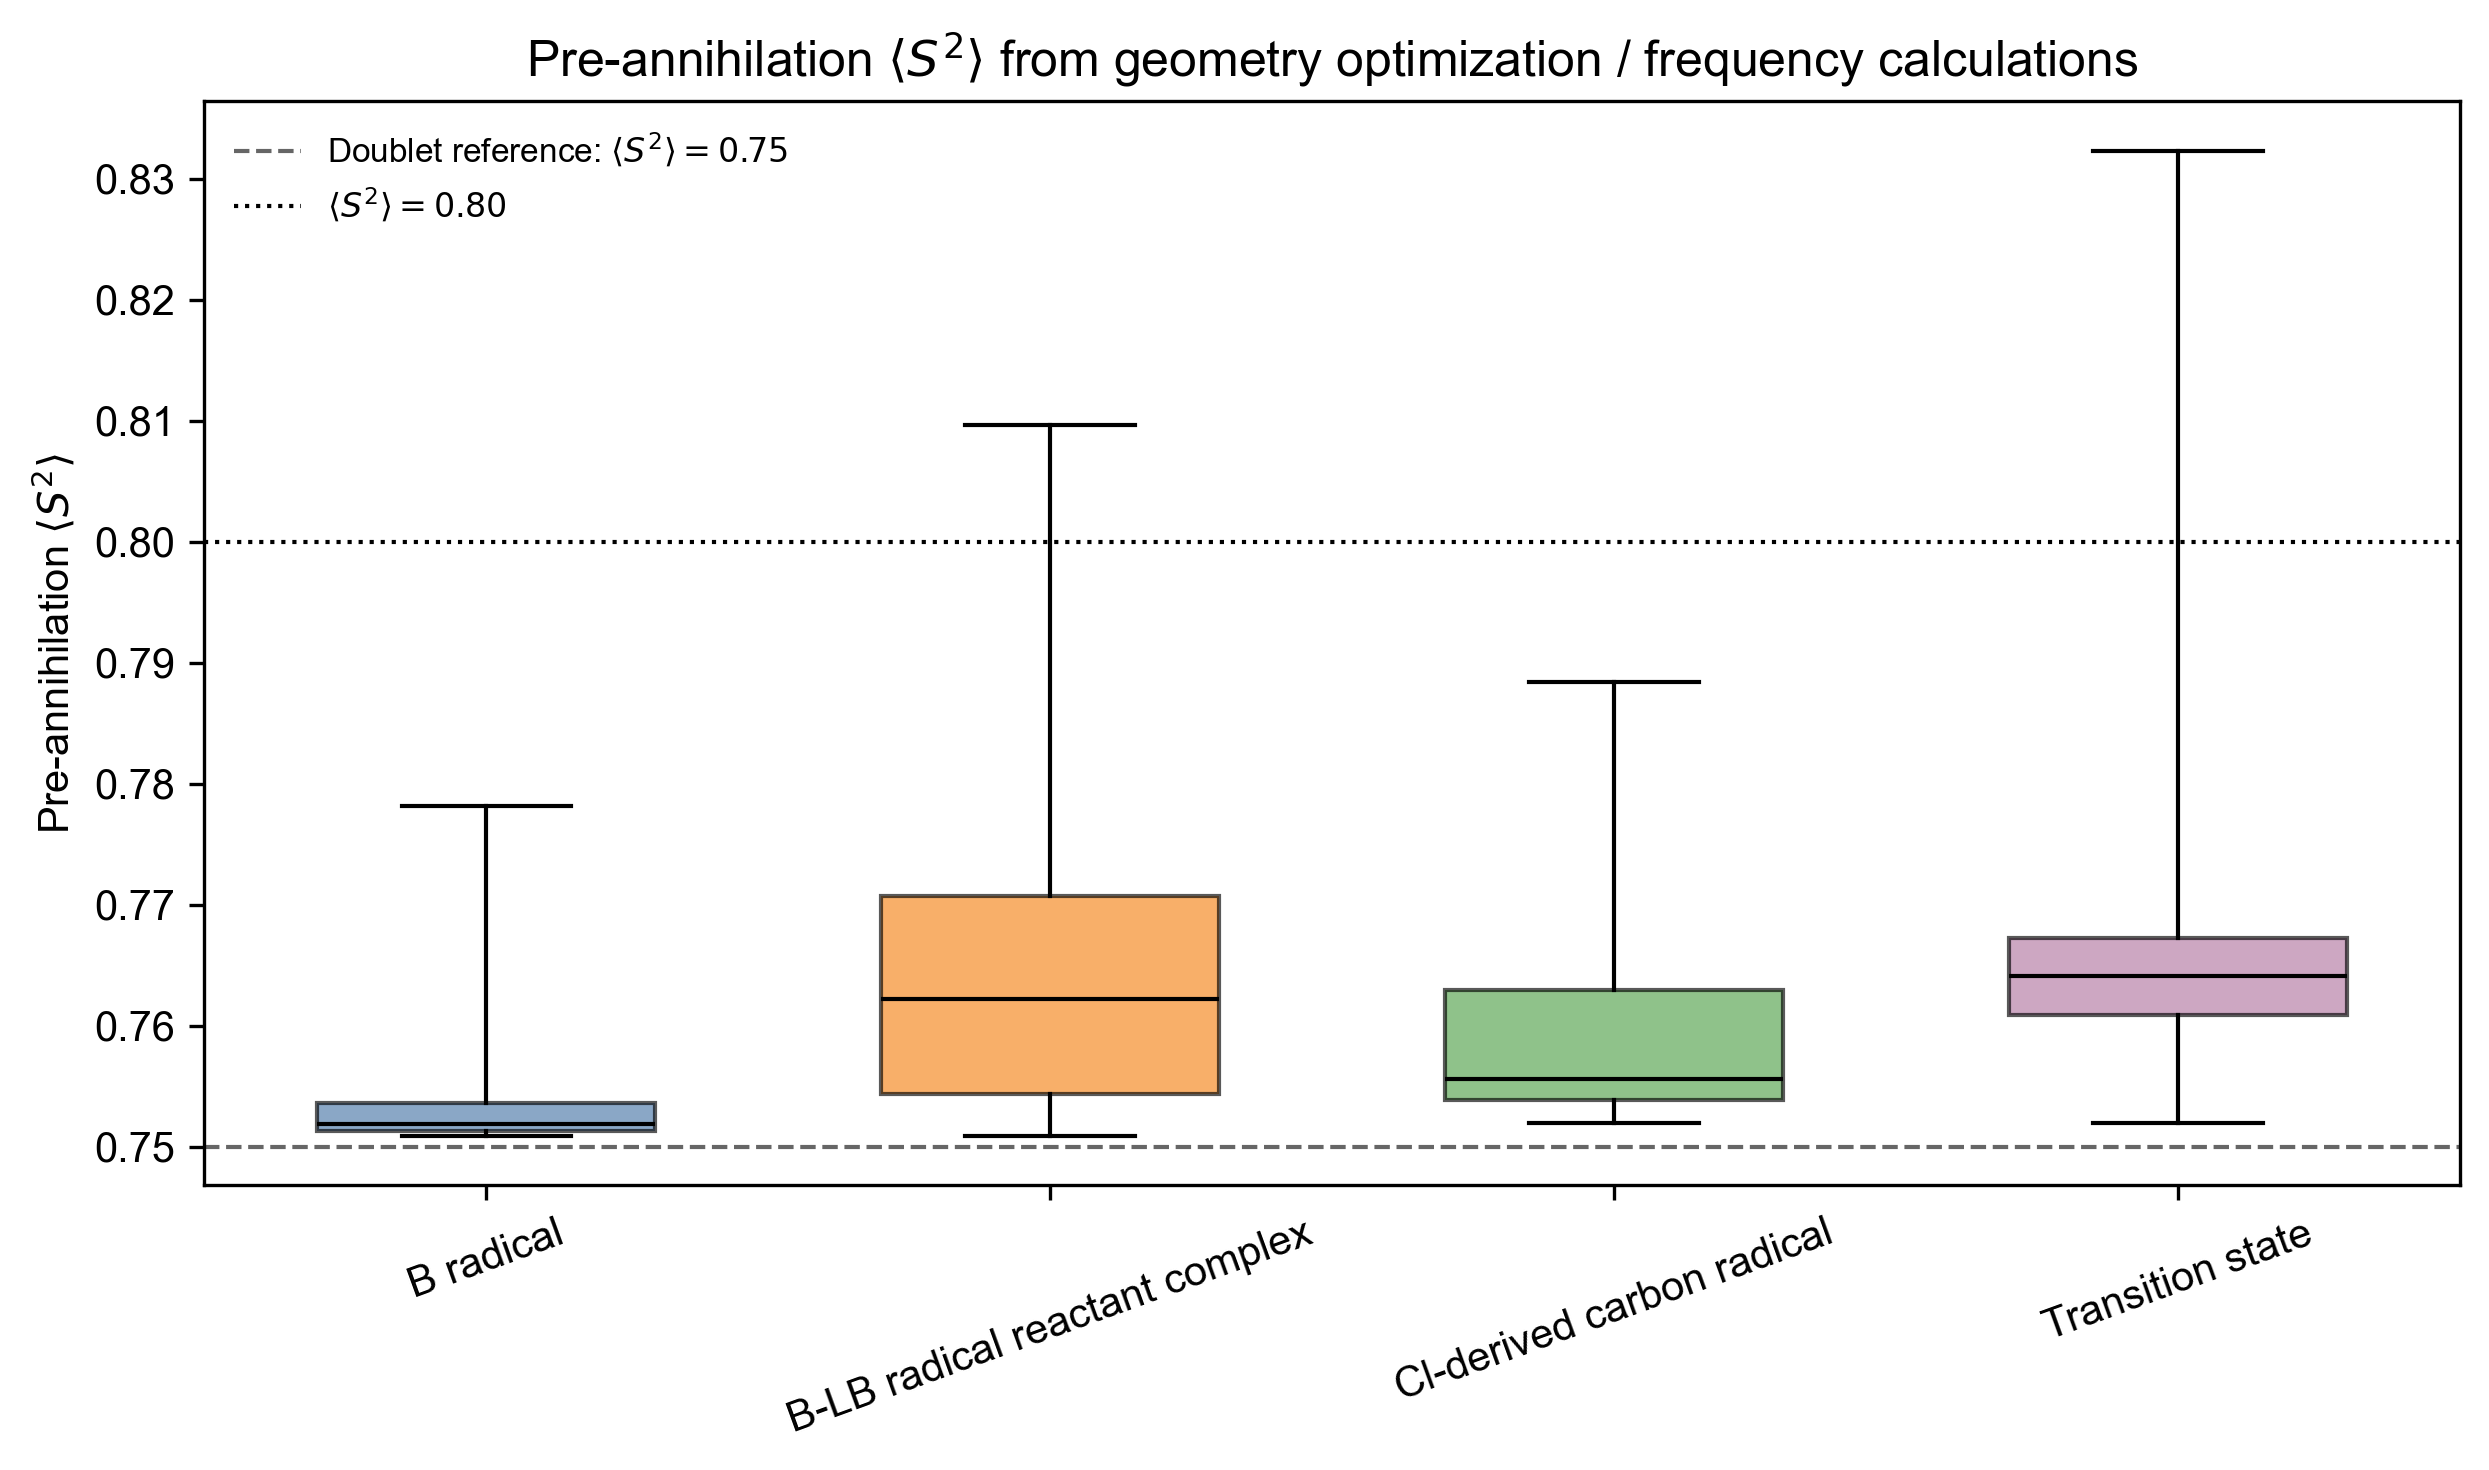

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantComponent_SpinContamination_Distribution_OptimizationFrequency.png
Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantComponent_SpinContamination_Distribution.png


C:\Users\Jackie\AppData\Local\Temp\ipykernel_44820\2812092287.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=labels, whis=(0, 100), showfliers=False, patch_artist=True, widths=0.6)


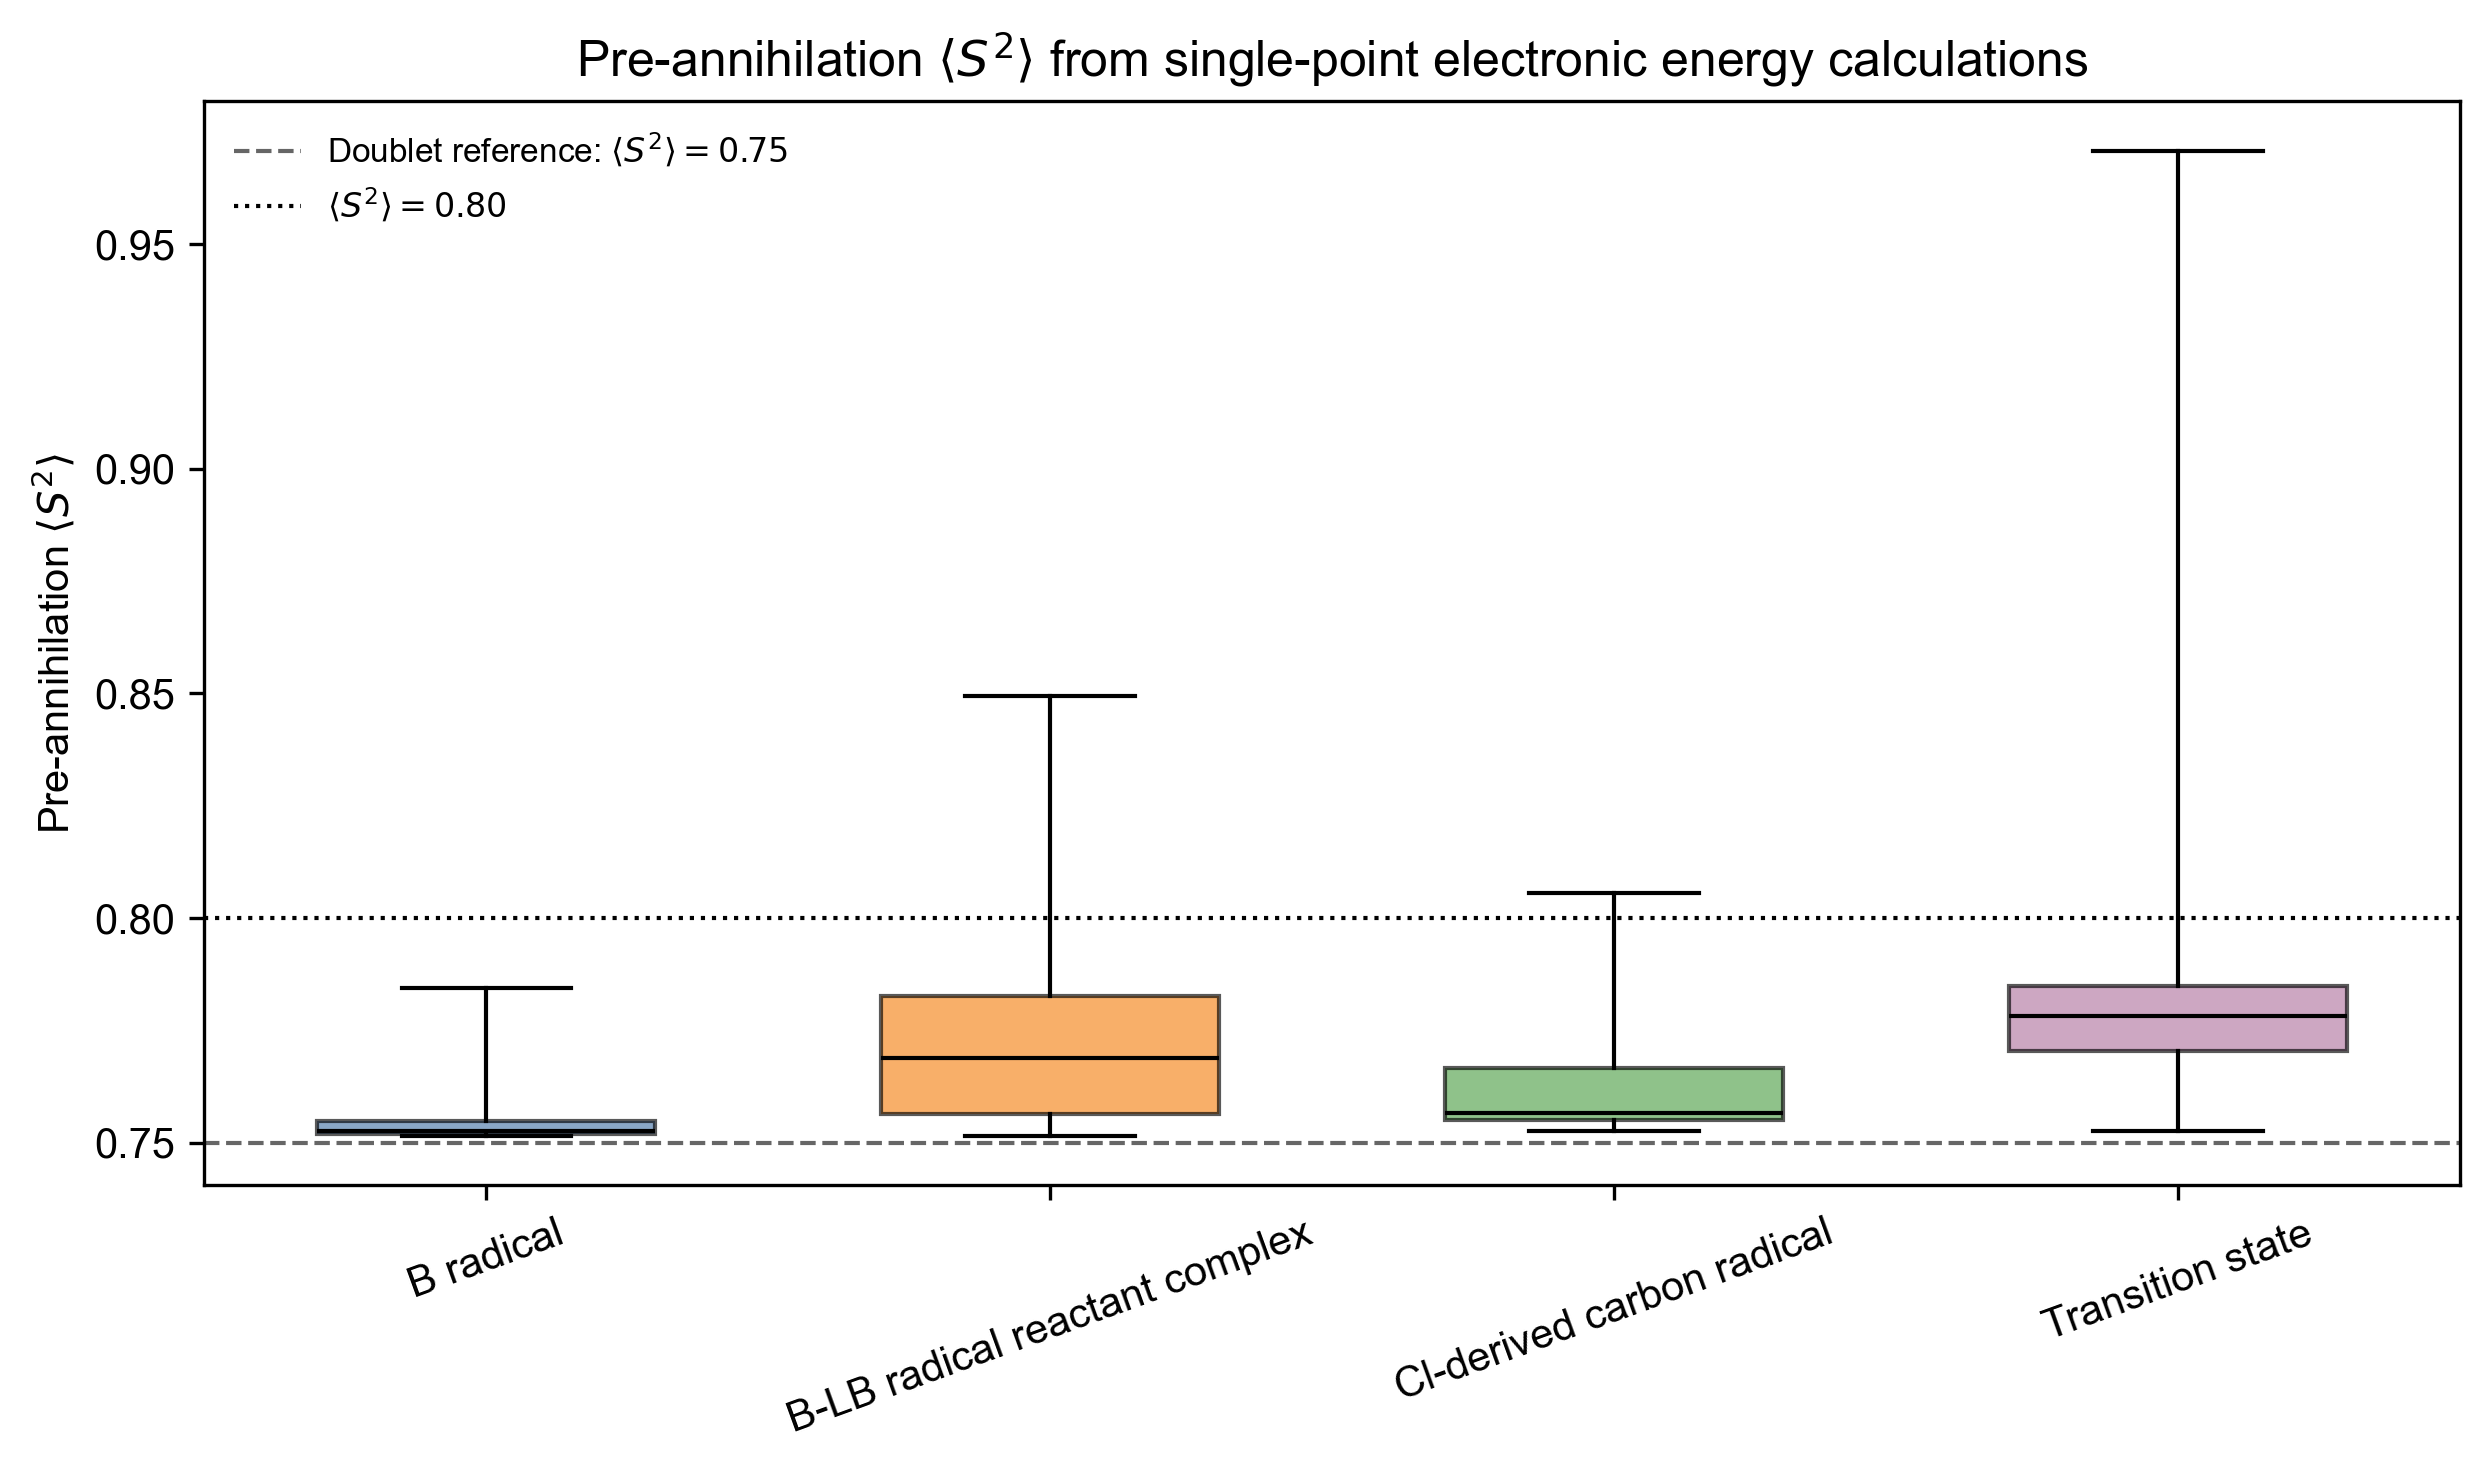

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantComponent_SpinContamination_Distribution_SinglePointEnergy.png


In [9]:
component_summary = (
    reactant_spin_df
    .dropna(subset=["s2_before_annihilation"])
    .groupby(["species_class", "calc_stage"])
    .agg(
        n=("species_key", "nunique"),
        mean_s2=("s2_before_annihilation", "mean"),
        median_s2=("s2_before_annihilation", "median"),
        p95_s2=("s2_before_annihilation", lambda s: s.quantile(0.95)),
        max_s2=("s2_before_annihilation", "max"),
        high_s2_n=("s2_before_annihilation", lambda s: (s >= S2_HIGH_VALUE_CUTOFF).sum()),
    )
    .reset_index()
)

component_summary["high_s2_frac"] = component_summary["high_s2_n"] / component_summary["n"]
component_summary["species_label"] = component_summary["species_class"].map(SPECIES_LABELS)
component_summary["calc_stage_label"] = component_summary["calc_stage"].map(CALC_STAGE_LABELS)
component_summary = component_summary.sort_values(
    by=["calc_stage", "species_class"],
    key=lambda s: s.map(stage_sort_key) if s.name == "calc_stage" else s.map(species_sort_key),
).reset_index(drop=True)
component_summary.to_csv(OUTPUT_DIR / "reactant_component_spin_summary.csv", index=False)
display(component_summary)


def save_component_stage_boxplot(stage: str, figure_path: Path, *, alias_path: Path | None = None) -> None:
    plot_components = reactant_spin_df[
        reactant_spin_df["calc_stage"].eq(stage)
    ].dropna(subset=["s2_before_annihilation"]).copy()
    species_order = [species for species in SPECIES_ORDER if species in plot_components["species_class"].unique()]
    labels = [SPECIES_LABELS[species] for species in species_order]
    data = [
        plot_components.loc[plot_components["species_class"].eq(species), "s2_before_annihilation"]
        for species in species_order
    ]

    fig, ax = plt.subplots(figsize=(8.4, 5), dpi=300)
    box = ax.boxplot(data, labels=labels, whis=(0, 100), showfliers=False, patch_artist=True, widths=0.6)
    for patch, species in zip(box["boxes"], species_order):
        patch.set_facecolor(COMPONENT_COLORS[species])
        patch.set_alpha(0.65)
    for median in box["medians"]:
        median.set_color("black")

    ax.axhline(
        S2_REFERENCE_DOUBLET,
        color="#666666",
        lw=1,
        ls="--",
        label=r"Doublet reference: $\langle S^2 \rangle = 0.75$",
    )
    ax.axhline(
        S2_HIGH_VALUE_CUTOFF,
        color="black",
        lw=1,
        ls=":",
        label=rf"$\langle S^2 \rangle = {S2_HIGH_VALUE_CUTOFF:.2f}$",
    )
    ax.set_ylabel(r"Pre-annihilation $\langle S^2 \rangle$")
    ax.set_title(
        rf"Pre-annihilation $\langle S^2 \rangle$ from {CALC_STAGE_LABELS[stage].lower()} calculations"
    )
    ax.legend(frameon=False, fontsize=8)
    ax.tick_params(axis="x", labelrotation=20)
    fig.tight_layout()
    fig.savefig(figure_path, bbox_inches="tight")
    if alias_path is not None:
        fig.savefig(alias_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {figure_path}")
    if alias_path is not None:
        print(f"Saved: {alias_path}")


opt_stage_fig = FIGURE_DIR / "Revision_ReactantComponent_SpinContamination_Distribution_OptimizationFrequency.png"
single_point_fig = FIGURE_DIR / "Revision_ReactantComponent_SpinContamination_Distribution_SinglePointEnergy.png"
legacy_opt_fig = FIGURE_DIR / "Revision_ReactantComponent_SpinContamination_Distribution.png"

save_component_stage_boxplot("opt_freq", opt_stage_fig, alias_path=legacy_opt_fig)
save_component_stage_boxplot("single_point", single_point_fig)


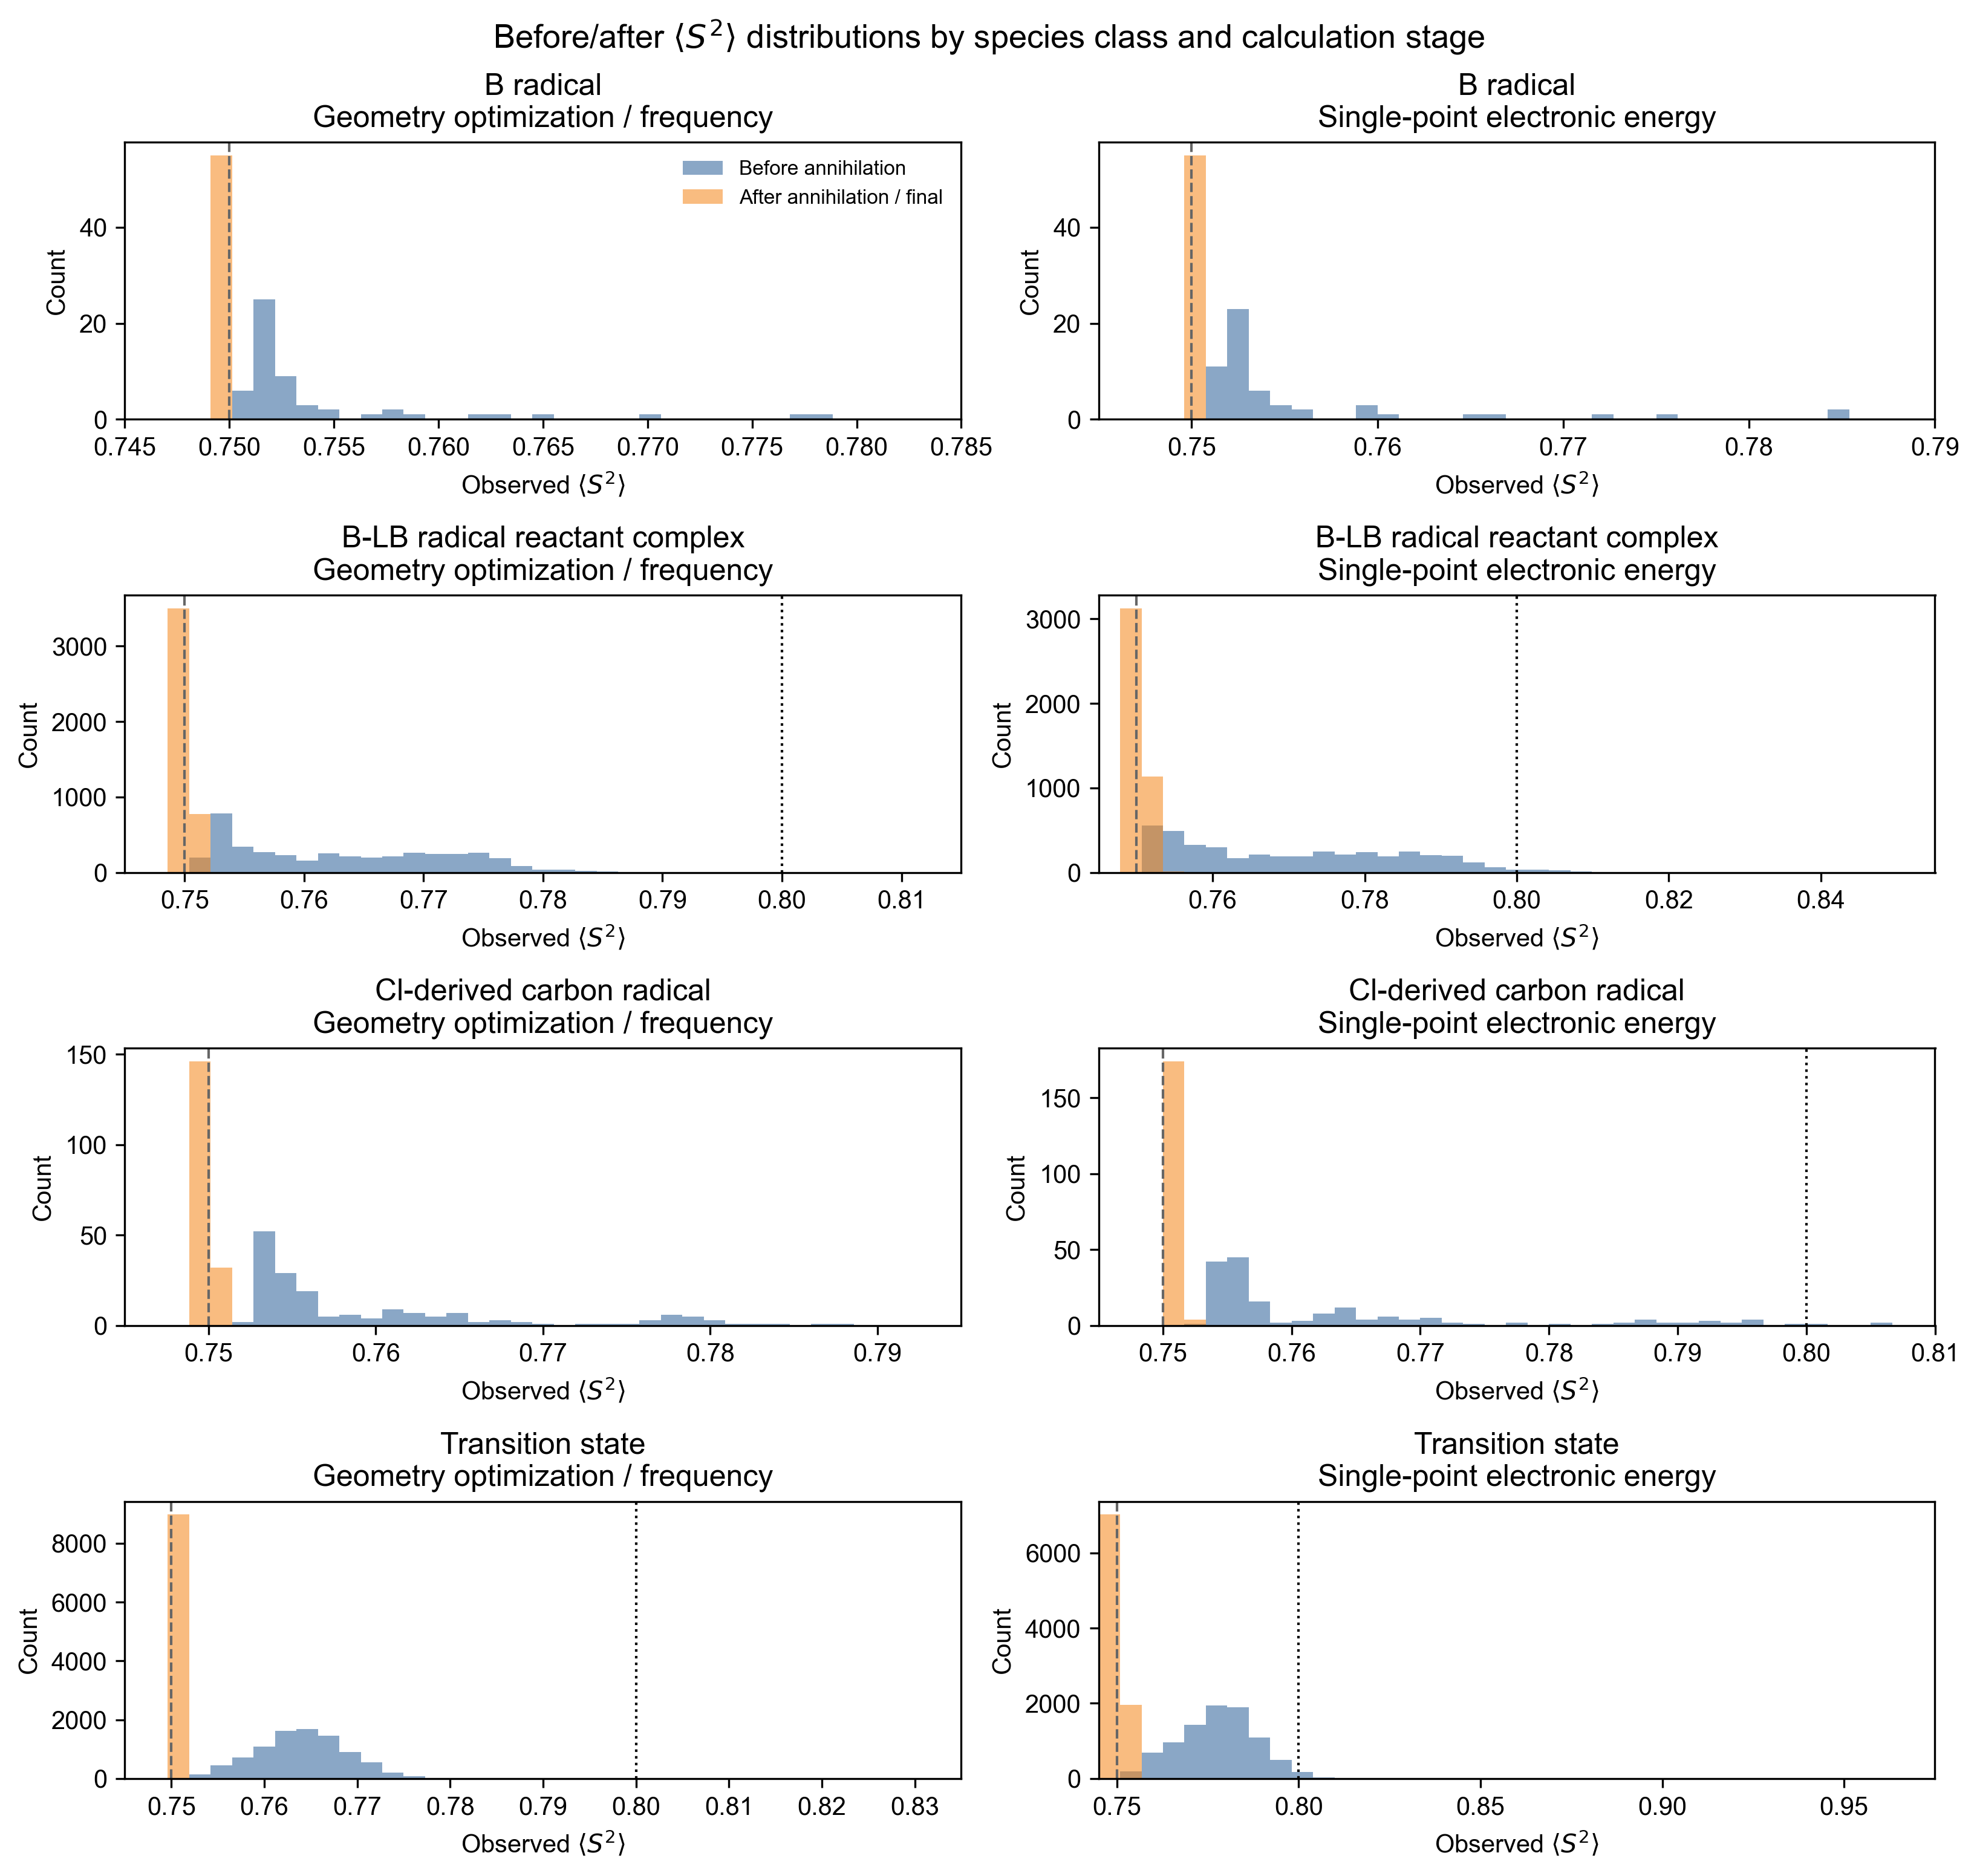

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantComponent_SpinContamination_BeforeAfter_Distribution.png


,species_class,species_label,calc_stage,calc_stage_label,n,min_before,max_before,min_final,max_final
0,B_radical,B radical,opt_freq,Geometry optimization / frequency,55,0.7509,0.7782,0.75,0.7501
1,B_radical,B radical,single_point,Single-point electronic energy,55,0.7515,0.7844,0.75,0.7503
2,BN_complex_r,B-LB radical reactant complex,opt_freq,Geometry optimization / frequency,4271,0.7509,0.8096,0.75,0.7524
3,BN_complex_r,B-LB radical reactant complex,single_point,Single-point electronic energy,4271,0.7515,0.8494,0.75,0.7564
4,C_radical_from_Cl_p,Cl-derived carbon radical,opt_freq,Geometry optimization / frequency,178,0.7520,0.7884,0.75,0.7510
5,C_radical_from_Cl_p,Cl-derived carbon radical,single_point,Single-point electronic energy,178,0.7527,0.8056,0.75,0.7527
6,Transition_state,Transition state,opt_freq,Geometry optimization / frequency,8980,0.7520,0.8323,0.75,0.7526
7,Transition_state,Transition state,single_point,Single-point electronic energy,8980,0.7527,0.9708,0.75,0.7628


In [8]:
before_after_summary_rows = []
fig, axes = plt.subplots(
    len(SPECIES_ORDER),
    len(CALC_STAGE_ORDER),
    figsize=(11.0, 10.5),
    dpi=300,
)

for row_idx, species_class in enumerate(SPECIES_ORDER):
    for col_idx, stage in enumerate(CALC_STAGE_ORDER):
        ax = axes[row_idx, col_idx]
        plot_df = reactant_spin_df[
            reactant_spin_df["species_class"].eq(species_class)
            & reactant_spin_df["calc_stage"].eq(stage)
        ].dropna(subset=["s2_before_annihilation", "s2_final"]).copy()

        if plot_df.empty:
            ax.set_visible(False)
            continue

        full_min = np.floor((plot_df[["s2_before_annihilation", "s2_final"]].min().min() - 0.002) / 0.005) * 0.005
        full_max = plot_df[["s2_before_annihilation", "s2_final"]].max().max()
        bin_max = np.ceil((full_max + 0.002) / 0.005) * 0.005
        if bin_max <= full_min:
            bin_max = full_min + 0.01
        bins = np.linspace(full_min, bin_max, 40)

        ax.hist(
            plot_df["s2_before_annihilation"],
            bins=bins,
            color="#4C78A8",
            alpha=0.65,
            label="Before annihilation",
        )
        ax.hist(
            plot_df["s2_final"],
            bins=bins,
            color="#F58518",
            alpha=0.55,
            label="After annihilation / final",
        )
        ax.axvline(
            S2_REFERENCE_DOUBLET,
            color="#666666",
            lw=1,
            ls="--",
        )
        ax.axvline(
            S2_HIGH_VALUE_CUTOFF,
            color="black",
            lw=1,
            ls=":",
        )
        ax.set_xlim(full_min, bin_max)
        ax.set_xlabel(r"Observed $\langle S^2 \rangle$")
        ax.set_ylabel("Count")
        ax.set_title(f"{SPECIES_LABELS[species_class]}\n{CALC_STAGE_LABELS[stage]}")
        if row_idx == 0 and col_idx == 0:
            ax.legend(frameon=False, fontsize=8)

        before_after_summary_rows.append({
            "species_class": species_class,
            "species_label": SPECIES_LABELS[species_class],
            "calc_stage": stage,
            "calc_stage_label": CALC_STAGE_LABELS[stage],
            "n": len(plot_df),
            "min_before": plot_df["s2_before_annihilation"].min(),
            "max_before": plot_df["s2_before_annihilation"].max(),
            "min_final": plot_df["s2_final"].min(),
            "max_final": plot_df["s2_final"].max(),
        })

fig.suptitle(r"Before/after $\langle S^2 \rangle$ distributions by species class and calculation stage", fontsize=13)
fig.tight_layout()
before_after_fig = FIGURE_DIR / "Revision_ReactantComponent_SpinContamination_BeforeAfter_Distribution.png"
fig.savefig(before_after_fig, bbox_inches="tight")
plt.show()
print(f"Saved: {before_after_fig}")

before_after_summary_df = pd.DataFrame(before_after_summary_rows)
before_after_summary_df.to_csv(OUTPUT_DIR / "reactant_component_spin_before_after_summary.csv", index=False)
display(before_after_summary_df)


## 5. Recompute BEP Residuals And Label Outliers

The outlier label uses the global BEP fit residual:

`outlier = abs(residual) >= OUTLIER_SIGMA * residual_std`

The notebook also records a top-5-percent absolute residual label for sensitivity checks.

In [7]:
x = reaction_df[REACTION_ENERGY_COLUMN].to_numpy(dtype=float)
y = reaction_df[BARRIER_COLUMN].to_numpy(dtype=float)
bep_coef = np.polyfit(x, y, deg=1)
bep_fit = np.polyval(bep_coef, x)
bep_residual = y - bep_fit
bep_abs_residual = np.abs(bep_residual)
bep_residual_std = np.std(bep_residual, ddof=1)
bep_outlier_cutoff = OUTLIER_SIGMA * bep_residual_std
bep_top5_cutoff = np.quantile(bep_abs_residual, 0.95)

residual_df = reaction_df[[
    "identifier",
    "B_Index",
    "N_Index",
    "N_Atomid",
    "Cl_Index",
    "conf_idxs_ts",
    REACTION_ENERGY_COLUMN,
    BARRIER_COLUMN,
]].copy()
residual_df["bep_fit_deltaGa(kcal/mol)"] = bep_fit
residual_df["bep_residual(kcal/mol)"] = bep_residual
residual_df["bep_abs_residual(kcal/mol)"] = bep_abs_residual
residual_df["bep_outlier_2sigma"] = residual_df["bep_abs_residual(kcal/mol)"] >= bep_outlier_cutoff
residual_df["bep_outlier_top5pct"] = residual_df["bep_abs_residual(kcal/mol)"] >= bep_top5_cutoff

print(f"BEP fit: DeltaG_act = {bep_coef[0]:.3f} * DeltaG_rxn + {bep_coef[1]:.3f}")
print(f"Residual std: {bep_residual_std:.3f} kcal/mol")
print(f"2-sigma outlier cutoff: {bep_outlier_cutoff:.3f} kcal/mol")
print(f"Top-5% abs residual cutoff: {bep_top5_cutoff:.3f} kcal/mol")
print(f"2-sigma outliers: {residual_df['bep_outlier_2sigma'].sum():,}")
display(residual_df.sort_values("bep_abs_residual(kcal/mol)", ascending=False).head(10))

BEP fit: DeltaG_act = 0.460 * DeltaG_rxn + 30.257
Residual std: 4.372 kcal/mol
2-sigma outlier cutoff: 8.744 kcal/mol
Top-5% abs residual cutoff: 8.570 kcal/mol
2-sigma outliers: 445


,identifier,B_Index,N_Index,N_Atomid,Cl_Index,conf_idxs_ts,deltaG(kcal/mol),deltaGa(kcal/mol),bep_fit_deltaGa(kcal/mol),bep_residual(kcal/mol),bep_abs_residual(kcal/mol),bep_outlier_2sigma,bep_outlier_top5pct
3460,B_00409_Nu_00354_Cl_00476_0000,409,354,5,476,0,-35.248369,53.647416,14.059095,39.588321,39.588321,True,True
1476,B_00392_Nu_00260_Cl_00485_0000,392,260,10,485,0,-9.196954,0.919382,26.030993,-25.111611,25.111611,True,True
8826,B_00439_Nu_00143_Cl_00485_0000,439,143,2,485,0,-5.277714,51.632758,27.832075,23.800683,23.800683,True,True
2324,B_00400_Nu_00132_Cl_00483_0000,400,132,4,483,0,-12.577673,1.205697,24.477387,-23.271690,23.271690,True,True
2309,B_00400_Nu_00092_Cl_00485_0010,400,92,4,485,10,-14.580151,0.300679,23.557151,-23.256472,23.256472,True,True
8306,B_00432_Nu_00233_Cl_00485_0000,432,233,2,485,0,-6.583667,4.646161,27.231926,-22.585765,22.585765,True,True
8509,B_00434_Nu_00039_Cl_00483_0000,434,39,1,483,0,-5.808391,5.339824,27.588203,-22.248379,22.248379,True,True
2763,B_00405_Nu_00037_Cl_00483_0000,405,37,3,483,0,-9.553311,5.004074,25.867229,-20.863155,20.863155,True,True
6119,B_00421_Nu_00143_Cl_00485_0000,421,143,2,485,0,-4.216298,49.033314,28.319847,20.713467,20.713467,True,True
7746,B_00429_Nu_00332_Cl_00553_0000,429,332,2,553,0,-8.425417,5.938327,26.385552,-20.447224,20.447224,True,True


## 6. Merge Spin Metrics With Outlier Labels

In [8]:
merge_cols = [
    "identifier",
    "log_found",
    "log_path",
    "log_source",
    "log_name_variant",
    "normal_termination",
    "multiplicity",
    "expected_s2",
    "s2_before_annihilation",
    "s2_after_annihilation",
    "s2_final",
    "spin_contamination_before",
    "spin_contamination_after",
]

analysis_df = residual_df.merge(spin_df[merge_cols], on="identifier", how="left", validate="one_to_one")
analysis_df["high_spin_contamination"] = analysis_df["s2_before_annihilation"] >= S2_HIGH_VALUE_CUTOFF
analysis_df.to_csv(ANALYSIS_CSV, index=False)

print(f"Merged rows: {len(analysis_df):,}")
print(f"Rows with parsed S2: {analysis_df['s2_before_annihilation'].notna().sum():,}")
print(f"Rows at or above S2 = {S2_HIGH_VALUE_CUTOFF:.2f}: {analysis_df['high_spin_contamination'].sum():,}")
print(f"Wrote analysis table: {ANALYSIS_CSV}")
display(analysis_df.head())

Merged rows: 9,237
Rows with parsed S2: 9,237
Rows at or above S2 = 0.80: 16
Wrote analysis table: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\spin_contamination_outlier_association.csv


,identifier,B_Index,N_Index,N_Atomid,Cl_Index,conf_idxs_ts,deltaG(kcal/mol),deltaGa(kcal/mol),bep_fit_deltaGa(kcal/mol),bep_residual(kcal/mol),...,log_name_variant,normal_termination,multiplicity,expected_s2,s2_before_annihilation,s2_after_annihilation,s2_final,spin_contamination_before,spin_contamination_after,high_spin_contamination
0,B_00388_Nu_00000_Cl_00500_0012,388,0,2,500,12,-33.510445,15.690129,14.857756,0.832373,...,conf_specific,True,2,0.75,0.7579,0.75,0.75,0.0079,0.0,False
1,B_00388_Nu_00001_Cl_00466_0013,388,1,1,466,13,-41.280903,9.890297,11.286851,-1.396554,...,conf_specific,True,2,0.75,0.7526,0.75,0.75,0.0026,0.0,False
2,B_00388_Nu_00001_Cl_00474_0010,388,1,1,474,10,-23.956318,12.493770,19.248344,-6.754574,...,conf_specific,True,2,0.75,0.7558,0.75,0.75,0.0058,0.0,False
3,B_00388_Nu_00001_Cl_00475_0002,388,1,1,475,2,-28.161071,14.914297,17.316055,-2.401758,...,conf_specific,True,2,0.75,0.7586,0.75,0.75,0.0086,0.0,False
4,B_00388_Nu_00001_Cl_00476_0000,388,1,1,476,0,-38.631535,14.312536,12.504365,1.808171,...,conf_specific,True,2,0.75,0.7571,0.75,0.75,0.0071,0.0,False


## 4. Reaction-Level Reactant `<S**2>`

This maps the observed `BN_complex_r` geometry-optimization/frequency `<S**2>` onto each of the 9237 TS reactions and compares it with BEP residual outlier labels.


In [ ]:
bn_reactant_spin = (
    reactant_spin_df[
        reactant_spin_df["species_class"].eq("BN_complex_r")
        & reactant_spin_df["calc_stage"].eq("opt_freq")
    ][[
        "B_Index",
        "N_Index",
        "N_Atomid",
        "species_key",
        "log_path",
        "spin_contamination_before",
        "spin_contamination_after",
        "s2_before_annihilation",
        "s2_after_annihilation",
    ]]
    .rename(columns={
        "species_key": "reactant_bn_species_key",
        "log_path": "reactant_bn_log_path",
        "spin_contamination_before": "reactant_bn_spin_contamination_before",
        "spin_contamination_after": "reactant_bn_spin_contamination_after",
        "s2_before_annihilation": "reactant_bn_s2_before_annihilation",
        "s2_after_annihilation": "reactant_bn_s2_after_annihilation",
    })
)

reaction_reactant_spin_df = analysis_df.merge(
    bn_reactant_spin,
    on=["B_Index", "N_Index", "N_Atomid"],
    how="left",
    validate="many_to_one",
)
reaction_reactant_spin_df["max_ts_reactant_s2_before_annihilation"] = reaction_reactant_spin_df[
    ["s2_before_annihilation", "reactant_bn_s2_before_annihilation"]
].max(axis=1)
reaction_reactant_spin_df["max_ts_reactant_spin_contamination_before"] = reaction_reactant_spin_df[
    ["spin_contamination_before", "reactant_bn_spin_contamination_before"]
].max(axis=1)
reaction_reactant_spin_df["high_reactant_bn_spin_contamination"] = (
    reaction_reactant_spin_df["reactant_bn_s2_before_annihilation"] >= S2_HIGH_VALUE_CUTOFF
)
reaction_reactant_spin_df.to_csv(REACTION_REACTANT_SPIN_CSV, index=False)

print(f"Reaction rows with mapped BN reactant S2: {reaction_reactant_spin_df['reactant_bn_s2_before_annihilation'].notna().sum():,}/{len(reaction_reactant_spin_df):,}")
print(f"BN reactant rows at or above S2 = {S2_HIGH_VALUE_CUTOFF:.2f}: {reaction_reactant_spin_df['high_reactant_bn_spin_contamination'].sum():,}")
display(reaction_reactant_spin_df[[
    "identifier",
    "B_Index",
    "N_Index",
    "N_Atomid",
    "bep_abs_residual(kcal/mol)",
    "bep_outlier_2sigma",
    "s2_before_annihilation",
    "reactant_bn_s2_before_annihilation",
    "max_ts_reactant_s2_before_annihilation",
]].head())


,metric,flag,group,n,mean,median,p95,max,high_n,high_frac
0,s2_before_annihilation,bep_outlier_2sigma,False,8792,0.764308,0.7643,0.772145,0.8248,8,0.000910
1,s2_before_annihilation,bep_outlier_2sigma,True,445,0.763571,0.7622,0.775260,0.8323,8,0.017978
2,reactant_bn_s2_before_annihilation,bep_outlier_2sigma,False,8792,0.764833,0.7649,0.779700,0.8096,42,0.004777
3,reactant_bn_s2_before_annihilation,bep_outlier_2sigma,True,445,0.764651,0.7645,0.778800,0.8055,1,0.002247
4,max_ts_reactant_s2_before_annihilation,bep_outlier_2sigma,False,8792,0.767641,0.7671,0.779700,0.8248,50,0.005687
5,max_ts_reactant_s2_before_annihilation,bep_outlier_2sigma,True,445,0.767193,0.7670,0.782880,0.8323,9,0.020225


,metric,pearson,spearman
0,TS_spin_vs_abs_BEP_residual,-0.001928,-0.003679
1,BN_reactant_spin_vs_abs_BEP_residual,0.050202,0.077078
2,max_TS_BN_reactant_spin_vs_abs_BEP_residual,0.029733,0.048380


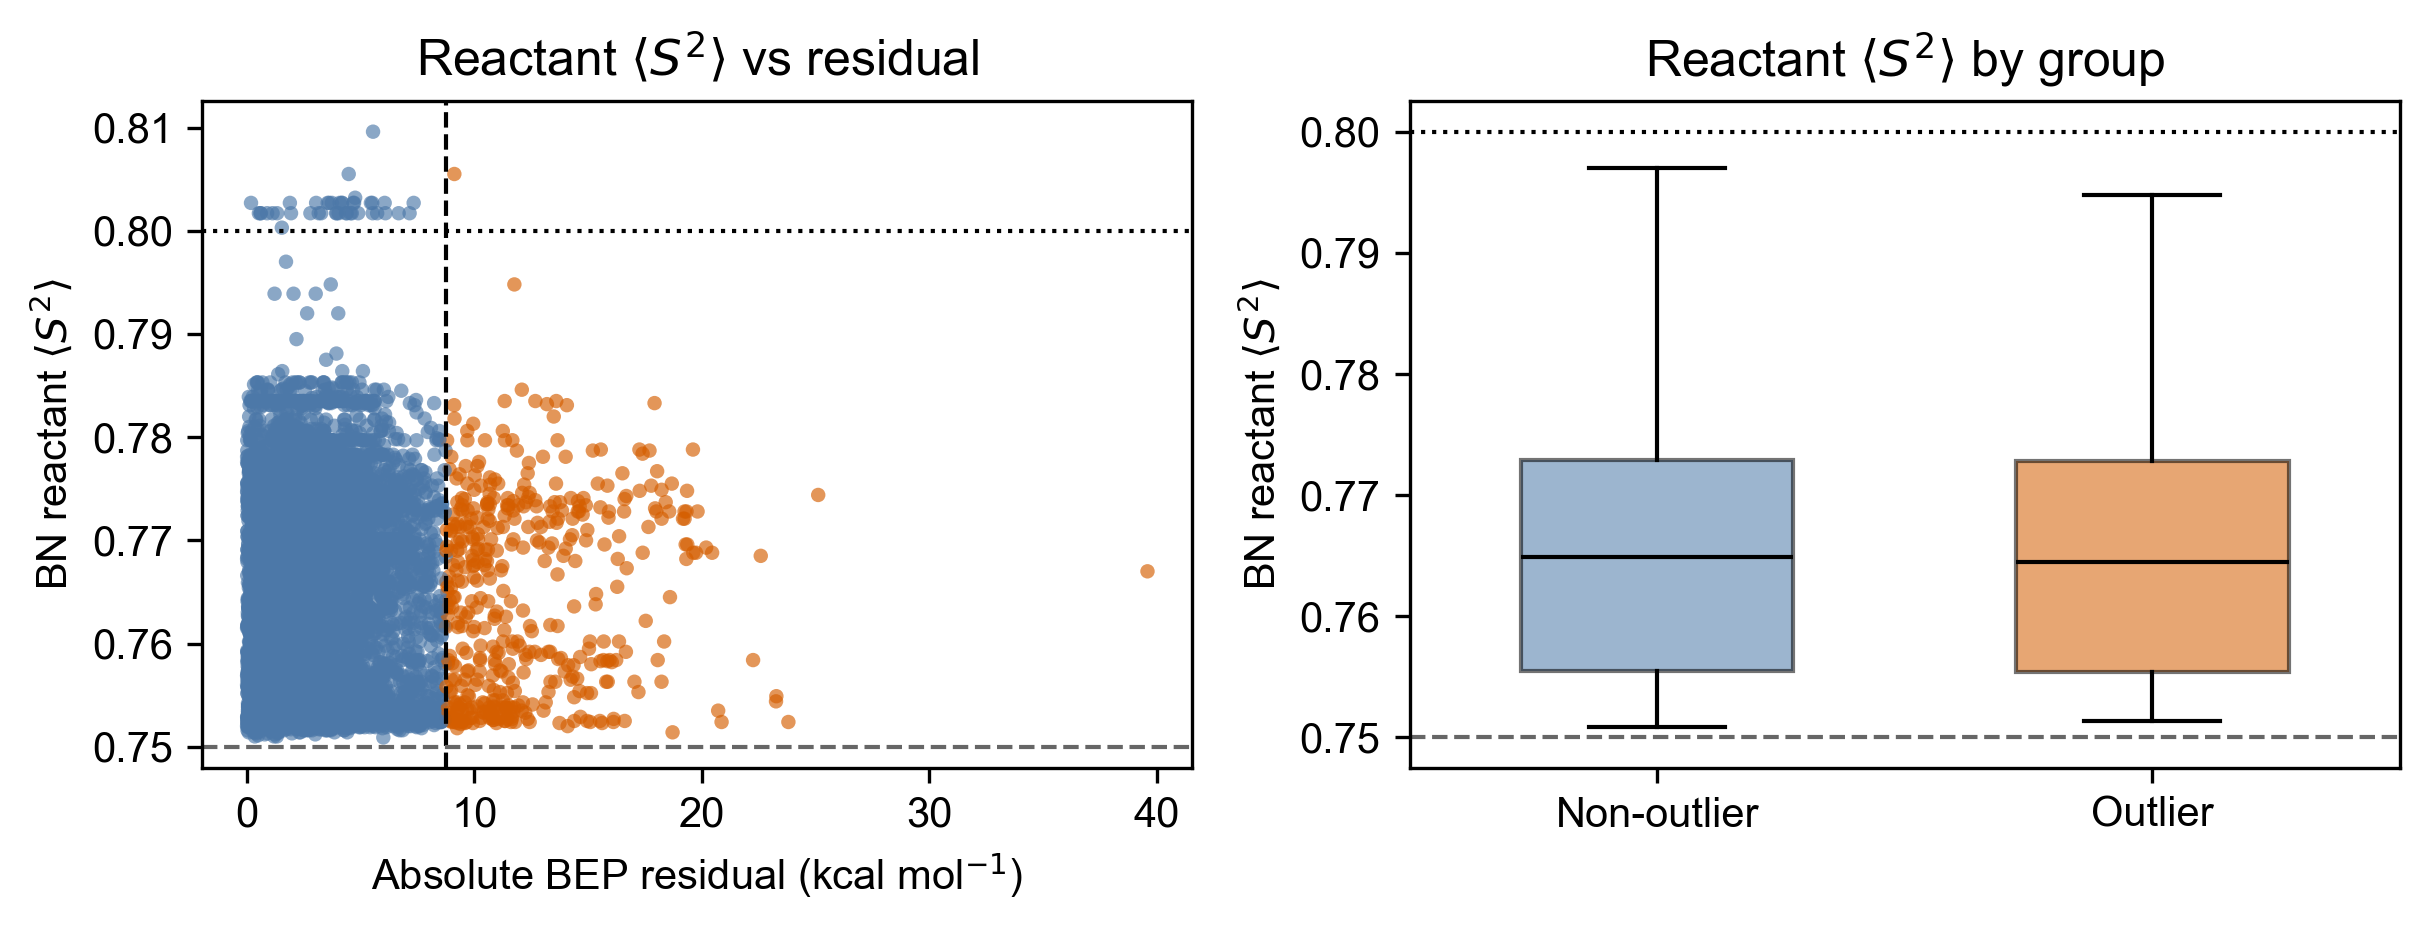

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantSpin_Outlier_Association.png


In [10]:
def reaction_spin_group_summary(df: pd.DataFrame, value_col: str, flag_col: str = "bep_outlier_2sigma") -> pd.DataFrame:
    rows = []
    for flag_value, group in df.dropna(subset=[value_col]).groupby(flag_col):
        values = group[value_col]
        rows.append({
            "metric": value_col,
            "flag": flag_col,
            "group": bool(flag_value),
            "n": len(group),
            "mean": values.mean(),
            "median": values.median(),
            "p95": values.quantile(0.95),
            "max": values.max(),
            "high_n": (values >= S2_HIGH_VALUE_CUTOFF).sum(),
            "high_frac": (values >= S2_HIGH_VALUE_CUTOFF).mean(),
        })
    return pd.DataFrame(rows)


reaction_spin_summary = pd.concat(
    [
        reaction_spin_group_summary(reaction_reactant_spin_df, "s2_before_annihilation"),
        reaction_spin_group_summary(reaction_reactant_spin_df, "reactant_bn_s2_before_annihilation"),
        reaction_spin_group_summary(reaction_reactant_spin_df, "max_ts_reactant_s2_before_annihilation"),
    ],
    ignore_index=True,
)

reaction_spin_correlations = pd.DataFrame([
    {
        "metric": "TS_spin_vs_abs_BEP_residual",
        "pearson": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "s2_before_annihilation"]].corr("pearson").iloc[0, 1],
        "spearman": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "s2_before_annihilation"]].corr("spearman").iloc[0, 1],
    },
    {
        "metric": "BN_reactant_spin_vs_abs_BEP_residual",
        "pearson": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "reactant_bn_s2_before_annihilation"]].corr("pearson").iloc[0, 1],
        "spearman": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "reactant_bn_s2_before_annihilation"]].corr("spearman").iloc[0, 1],
    },
    {
        "metric": "max_TS_BN_reactant_spin_vs_abs_BEP_residual",
        "pearson": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "max_ts_reactant_s2_before_annihilation"]].corr("pearson").iloc[0, 1],
        "spearman": reaction_reactant_spin_df[["bep_abs_residual(kcal/mol)", "max_ts_reactant_s2_before_annihilation"]].corr("spearman").iloc[0, 1],
    },
])

reaction_spin_summary.to_csv(OUTPUT_DIR / "reaction_reactant_spin_outlier_summary.csv", index=False)
reaction_spin_correlations.to_csv(OUTPUT_DIR / "reaction_reactant_spin_correlations.csv", index=False)
display(reaction_spin_summary)
display(reaction_spin_correlations)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2), dpi=300)
plot_df = reaction_reactant_spin_df.dropna(subset=["reactant_bn_s2_before_annihilation"]).copy()
colors = np.where(plot_df["bep_outlier_2sigma"], "#D55E00", "#4C78A8")
axes[0].scatter(
    plot_df["bep_abs_residual(kcal/mol)"],
    plot_df["reactant_bn_s2_before_annihilation"],
    s=12,
    c=colors,
    alpha=0.65,
    edgecolor="none",
)
axes[0].axvline(bep_outlier_cutoff, color="black", lw=1, ls="--")
axes[0].axhline(S2_REFERENCE_DOUBLET, color="#666666", lw=1, ls="--")
axes[0].axhline(S2_HIGH_VALUE_CUTOFF, color="black", lw=1, ls=":")
axes[0].set_xlabel(r"Absolute BEP residual (kcal mol$^{-1}$)")
axes[0].set_ylabel(r"BN reactant $\langle S^2 \rangle$")
axes[0].set_title(r"Reactant $\langle S^2 \rangle$ vs residual")

box_data = [
    plot_df.loc[~plot_df["bep_outlier_2sigma"], "reactant_bn_s2_before_annihilation"],
    plot_df.loc[plot_df["bep_outlier_2sigma"], "reactant_bn_s2_before_annihilation"],
]
box = axes[1].boxplot(box_data, labels=["Non-outlier", "Outlier"], showfliers=False, patch_artist=True, widths=0.55)
for patch, color in zip(box["boxes"], ["#4C78A8", "#D55E00"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for median in box["medians"]:
    median.set_color("black")
axes[1].axhline(S2_REFERENCE_DOUBLET, color="#666666", lw=1, ls="--")
axes[1].axhline(S2_HIGH_VALUE_CUTOFF, color="black", lw=1, ls=":")
axes[1].set_ylabel(r"BN reactant $\langle S^2 \rangle$")
axes[1].set_title(r"Reactant $\langle S^2 \rangle$ by group")

fig.tight_layout()
reactant_assoc_fig = FIGURE_DIR / "Revision_ReactantSpin_Outlier_Association.png"
fig.savefig(reactant_assoc_fig, bbox_inches="tight")
plt.show()
print(f"Saved: {reactant_assoc_fig}")

## 7. Distribution And Association Statistics

The association summary reports the pre-annihilation `<S**2>` values directly because they provide the stricter diagnostic.

In [11]:
def contamination_group_summary(df: pd.DataFrame, flag_col: str) -> pd.DataFrame:
    rows = []
    for flag_value, group in df.dropna(subset=["s2_before_annihilation"]).groupby(flag_col):
        s2_values = group["s2_before_annihilation"]
        rows.append({
            "flag": flag_col,
            "group": bool(flag_value),
            "n": len(group),
            "mean_s2": s2_values.mean(),
            "median_s2": s2_values.median(),
            "p95_s2": s2_values.quantile(0.95),
            "max_s2": s2_values.max(),
            "high_s2_n": group["high_spin_contamination"].sum(),
            "high_s2_frac": group["high_spin_contamination"].mean(),
            "mean_abs_bep_residual": group["bep_abs_residual(kcal/mol)"].mean(),
            "median_abs_bep_residual": group["bep_abs_residual(kcal/mol)"].median(),
        })
    return pd.DataFrame(rows)


def permutation_mean_difference(
    df: pd.DataFrame,
    flag_col: str,
    value_col: str = "s2_before_annihilation",
    n_perm: int = 10000,
    seed: int = RANDOM_SEED,
) -> dict:
    work = df[[flag_col, value_col]].dropna()
    flags = work[flag_col].astype(bool).to_numpy()
    values = work[value_col].to_numpy(dtype=float)
    if flags.sum() == 0 or (~flags).sum() == 0:
        return {"observed_mean_diff": np.nan, "permutation_p": np.nan, "n_perm": 0}

    observed = values[flags].mean() - values[~flags].mean()
    rng = np.random.default_rng(seed)
    permuted = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng.permutation(flags)
        permuted[i] = values[shuffled].mean() - values[~shuffled].mean()
    p_value = (np.sum(np.abs(permuted) >= abs(observed)) + 1) / (n_perm + 1)
    return {"observed_mean_diff": observed, "permutation_p": p_value, "n_perm": n_perm}


def risk_ratio_for_high_spin(df: pd.DataFrame, flag_col: str) -> dict:
    work = df[[flag_col, "high_spin_contamination"]].dropna()
    table = pd.crosstab(work[flag_col].astype(bool), work["high_spin_contamination"].astype(bool))
    for idx in [False, True]:
        if idx not in table.index:
            table.loc[idx] = 0
    for col in [False, True]:
        if col not in table.columns:
            table[col] = 0
    table = table.sort_index().sort_index(axis=1)

    # Haldane-Anscombe correction keeps the ratio finite if any cell is zero.
    high_out = table.loc[True, True] + 0.5
    total_out = table.loc[True].sum() + 1.0
    high_non = table.loc[False, True] + 0.5
    total_non = table.loc[False].sum() + 1.0
    return {
        "flag": flag_col,
        "high_s2_outlier": int(table.loc[True, True]),
        "total_outlier": int(table.loc[True].sum()),
        "high_s2_non_outlier": int(table.loc[False, True]),
        "total_non_outlier": int(table.loc[False].sum()),
        "risk_ratio_high_s2": (high_out / total_out) / (high_non / total_non),
    }


summary_tables = []
summary_tables.append(contamination_group_summary(analysis_df, "bep_outlier_2sigma"))
summary_tables.append(contamination_group_summary(analysis_df, "bep_outlier_top5pct"))
group_summary = pd.concat(summary_tables, ignore_index=True)

correlation_summary = pd.DataFrame([
    {
        "metric": "pearson_abs_residual_vs_s2_before",
        "value": analysis_df[["bep_abs_residual(kcal/mol)", "s2_before_annihilation"]].corr(method="pearson").iloc[0, 1],
    },
    {
        "metric": "spearman_abs_residual_vs_s2_before",
        "value": analysis_df[["bep_abs_residual(kcal/mol)", "s2_before_annihilation"]].corr(method="spearman").iloc[0, 1],
    },
])

permutation_summary = pd.DataFrame([
    {"flag": "bep_outlier_2sigma", **permutation_mean_difference(analysis_df, "bep_outlier_2sigma")},
    {"flag": "bep_outlier_top5pct", **permutation_mean_difference(analysis_df, "bep_outlier_top5pct")},
])

risk_summary = pd.DataFrame([
    risk_ratio_for_high_spin(analysis_df, "bep_outlier_2sigma"),
    risk_ratio_for_high_spin(analysis_df, "bep_outlier_top5pct"),
])

display(group_summary)
display(correlation_summary)
display(permutation_summary)
display(risk_summary)

summary_export = pd.concat(
    [
        group_summary.assign(summary_block="group_summary"),
        permutation_summary.assign(summary_block="permutation_test"),
        risk_summary.assign(summary_block="risk_ratio"),
        correlation_summary.assign(summary_block="correlation"),
    ],
    ignore_index=True,
    sort=False,
)
summary_export.to_csv(SUMMARY_CSV, index=False)
print(f"Wrote summary table: {SUMMARY_CSV}")

,flag,group,n,mean_s2,median_s2,p95_s2,max_s2,high_s2_n,high_s2_frac,mean_abs_bep_residual,median_abs_bep_residual
0,bep_outlier_2sigma,False,8792,0.764308,0.7643,0.772145,0.8248,8,0.000910,2.789864,2.430623
1,bep_outlier_2sigma,True,445,0.763571,0.7622,0.775260,0.8323,8,0.017978,12.367078,11.327242
2,bep_outlier_top5pct,False,8775,0.764309,0.7643,0.772100,0.8248,7,0.000798,2.778514,2.422485
3,bep_outlier_top5pct,True,462,0.763582,0.7621,0.775365,0.8323,9,0.019481,12.230247,11.205151


,metric,value
0,pearson_abs_residual_vs_s2_before,-0.001928
1,spearman_abs_residual_vs_s2_before,-0.003679


,flag,observed_mean_diff,permutation_p,n_perm
0,bep_outlier_2sigma,-0.000737,0.0049,10000
1,bep_outlier_top5pct,-0.000727,0.0047,10000


,flag,high_s2_outlier,total_outlier,high_s2_non_outlier,total_non_outlier,risk_ratio_high_s2
0,bep_outlier_2sigma,8,445,8,8792,19.715247
1,bep_outlier_top5pct,9,462,7,8775,24.009215


Wrote summary table: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\spin_contamination_outlier_summary.csv


## 8. Figures

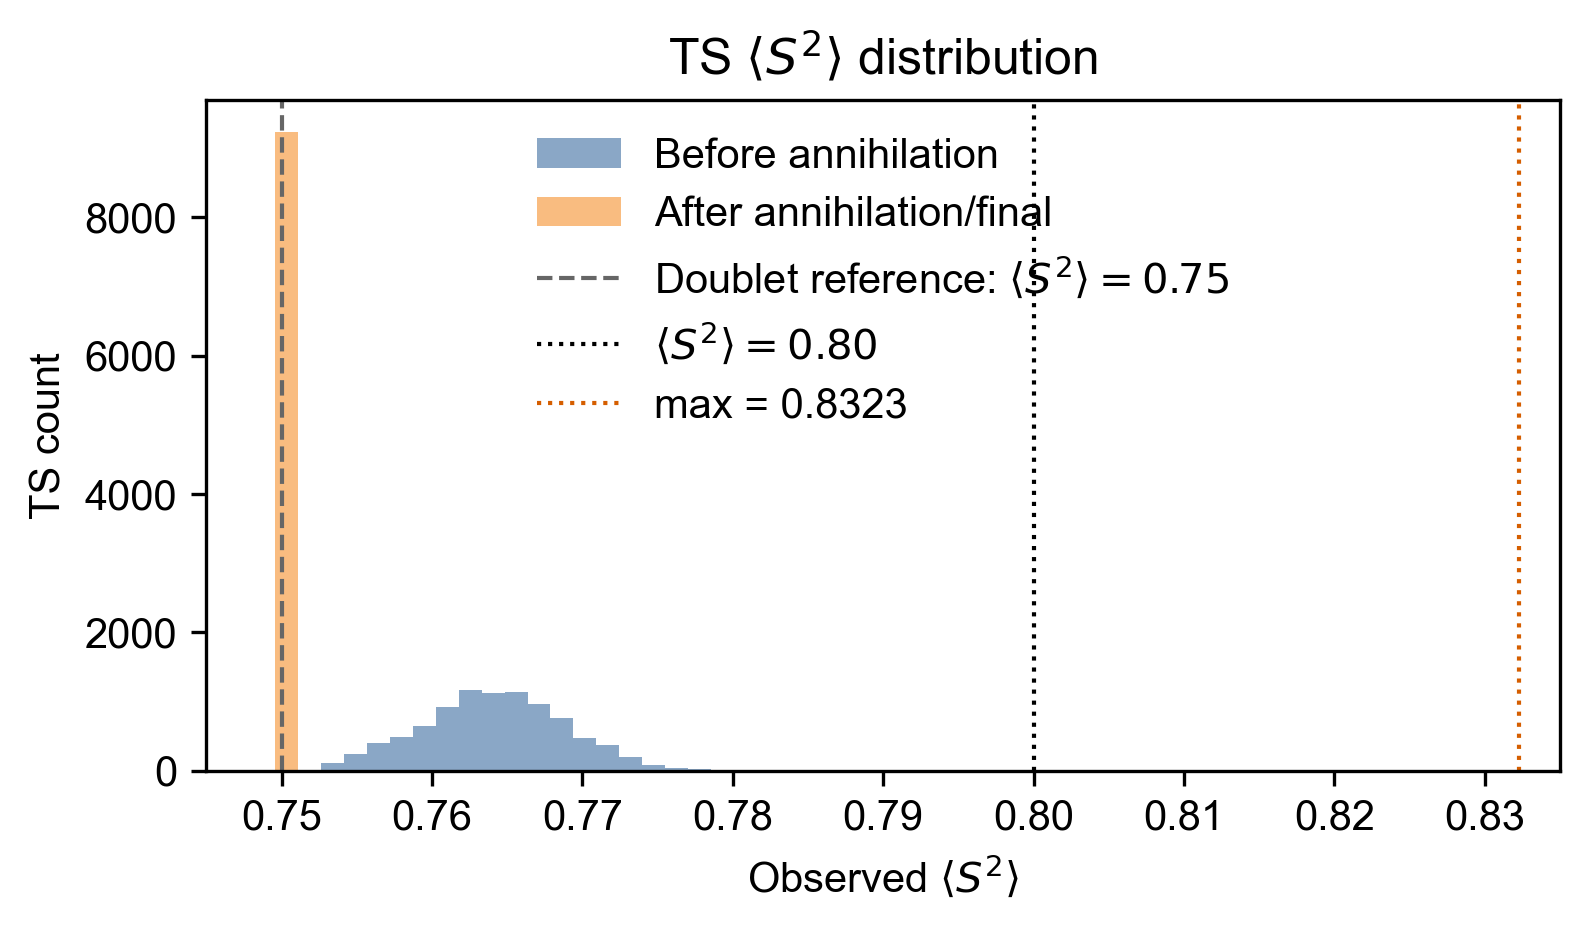

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_SpinContamination_Distribution.png
Observed pre-annihilation TS S2 range: 0.7520-0.8323
TS rows at or above 0.80: 16


In [12]:
plot_df = analysis_df.dropna(subset=["s2_before_annihilation", "s2_final"]).copy()

fig, ax = plt.subplots(figsize=(5.4, 3.2), dpi=300)
full_min = np.floor((plot_df[["s2_before_annihilation", "s2_final"]].min().min() - 0.002) / 0.005) * 0.005
full_max = plot_df[["s2_before_annihilation", "s2_final"]].max().max()
bin_max = np.ceil((full_max + 0.002) / 0.005) * 0.005
bins = np.linspace(full_min, bin_max, 60)

ax.hist(
    plot_df["s2_before_annihilation"],
    bins=bins,
    color="#4C78A8",
    alpha=0.65,
    label="Before annihilation",
)
ax.hist(
    plot_df["s2_final"],
    bins=bins,
    color="#F58518",
    alpha=0.55,
    label="After annihilation/final",
)
ax.axvline(S2_REFERENCE_DOUBLET, color="#666666", lw=1, ls="--", label=r"Doublet reference: $\langle S^2 \rangle=0.75$")
ax.axvline(S2_HIGH_VALUE_CUTOFF, color="black", lw=1, ls=":", label=r"$\langle S^2 \rangle=0.80$")
ax.axvline(full_max, color="#D55E00", lw=1, ls=":", label=f"max = {full_max:.4f}")
ax.set_xlim(full_min, bin_max)
ax.set_xlabel(r"Observed $\langle S^2 \rangle$")
ax.set_ylabel("TS count")
ax.legend(frameon=False)
ax.set_title(r"TS $\langle S^2 \rangle$ distribution")
fig.tight_layout()
dist_fig = FIGURE_DIR / "Revision_SpinContamination_Distribution.png"
fig.savefig(dist_fig, bbox_inches="tight")
plt.show()

print(f"Saved: {dist_fig}")
print(f"Observed pre-annihilation TS S2 range: {plot_df['s2_before_annihilation'].min():.4f}-{plot_df['s2_before_annihilation'].max():.4f}")
print(f"TS rows at or above {S2_HIGH_VALUE_CUTOFF:.2f}: {(plot_df['s2_before_annihilation'] >= S2_HIGH_VALUE_CUTOFF).sum():,}")

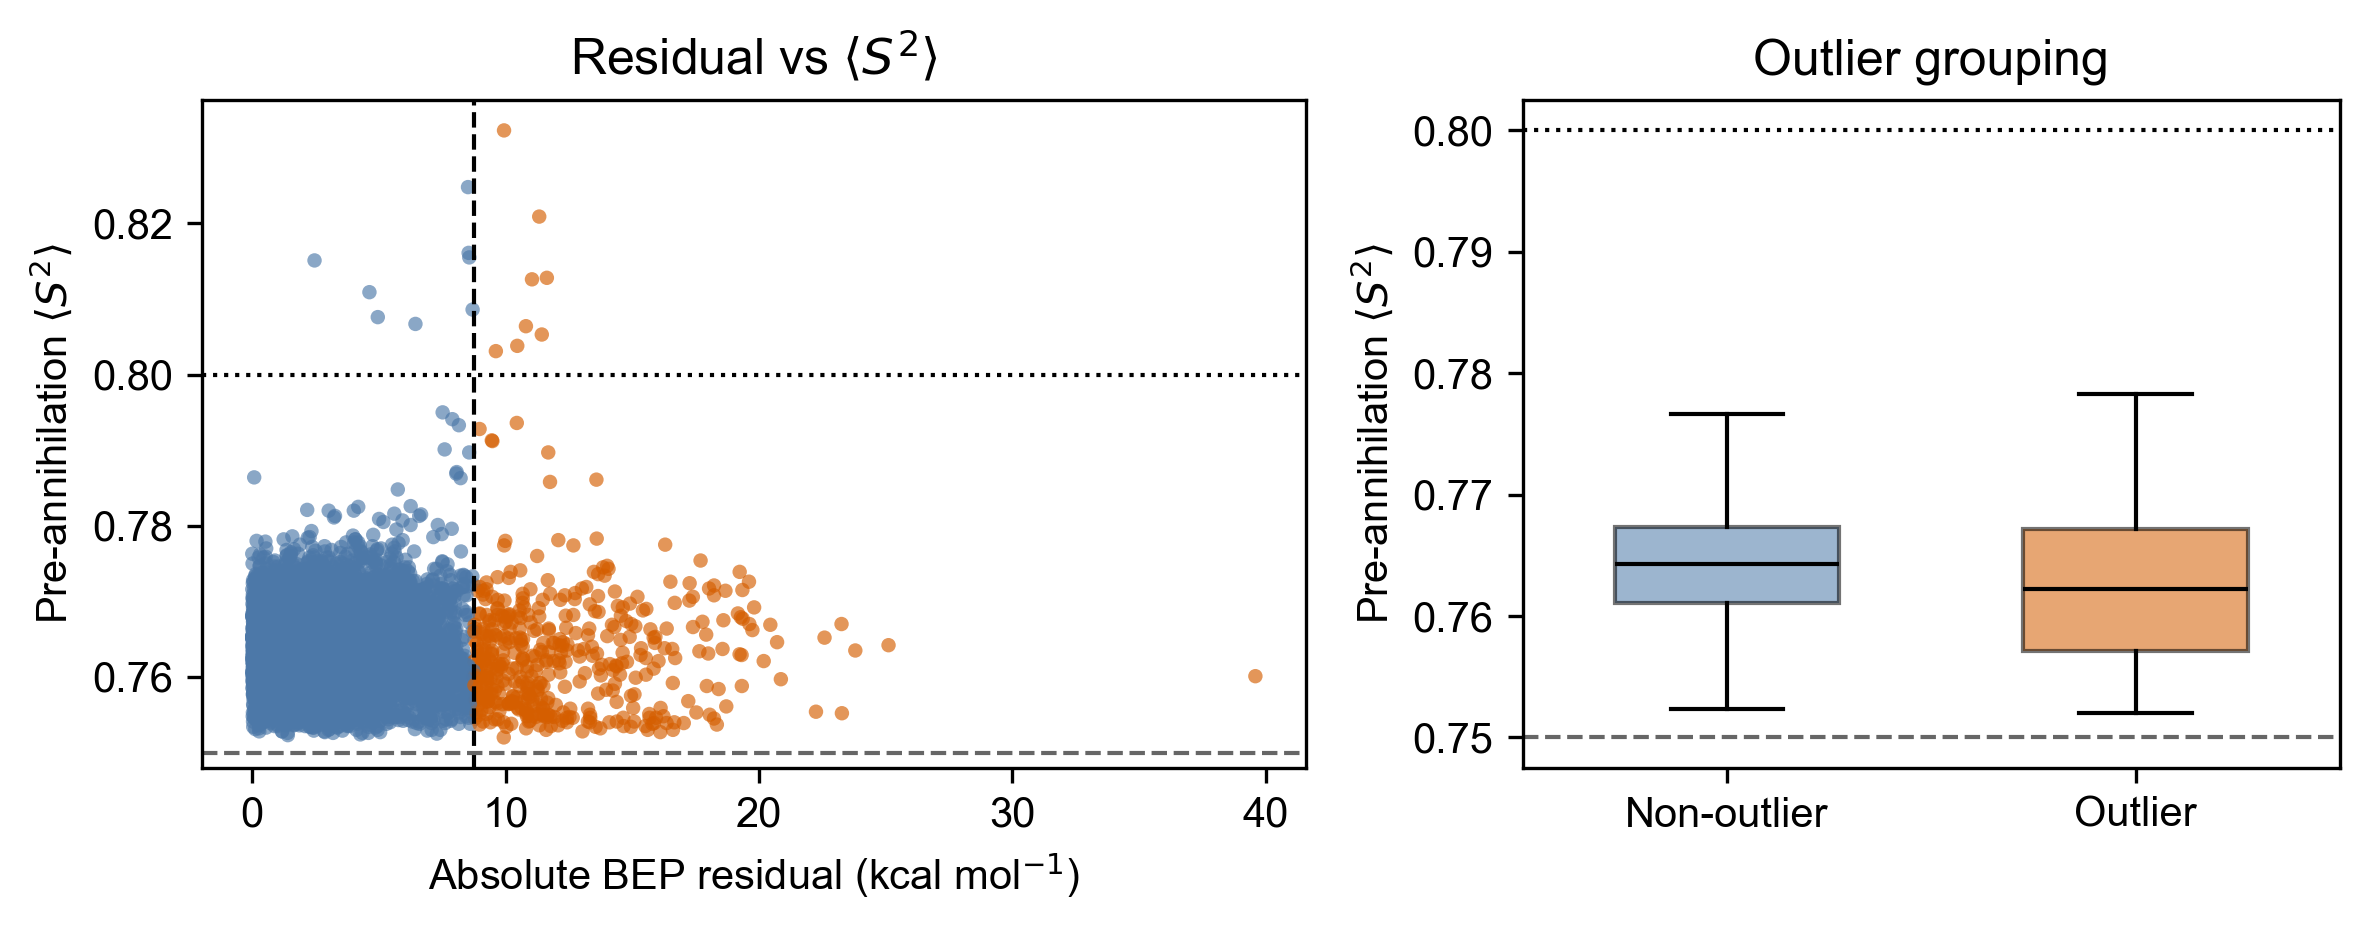

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_SpinContamination_Outlier_Association.png


In [13]:
plot_df = analysis_df.dropna(subset=["s2_before_annihilation", "bep_abs_residual(kcal/mol)"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.2), dpi=300, gridspec_kw={"width_ratios": [1.35, 1.0]})

colors = np.where(plot_df["bep_outlier_2sigma"], "#D55E00", "#4C78A8")
axes[0].scatter(
    plot_df["bep_abs_residual(kcal/mol)"],
    plot_df["s2_before_annihilation"],
    s=12,
    c=colors,
    alpha=0.65,
    edgecolor="none",
)
axes[0].axvline(bep_outlier_cutoff, color="black", lw=1, ls="--")
axes[0].axhline(S2_REFERENCE_DOUBLET, color="#666666", lw=1, ls="--")
axes[0].axhline(S2_HIGH_VALUE_CUTOFF, color="black", lw=1, ls=":")
axes[0].set_xlabel(r"Absolute BEP residual (kcal mol$^{-1}$)")
axes[0].set_ylabel(r"Pre-annihilation $\langle S^2 \rangle$")
axes[0].set_title(r"Residual vs $\langle S^2 \rangle$")

box_data = [
    plot_df.loc[~plot_df["bep_outlier_2sigma"], "s2_before_annihilation"],
    plot_df.loc[plot_df["bep_outlier_2sigma"], "s2_before_annihilation"],
]
box = axes[1].boxplot(
    box_data,
    labels=["Non-outlier", "Outlier"],
    showfliers=False,
    patch_artist=True,
    widths=0.55,
)
for patch, color in zip(box["boxes"], ["#4C78A8", "#D55E00"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
for median in box["medians"]:
    median.set_color("black")
axes[1].axhline(S2_REFERENCE_DOUBLET, color="#666666", lw=1, ls="--")
axes[1].axhline(S2_HIGH_VALUE_CUTOFF, color="black", lw=1, ls=":")
axes[1].set_ylabel(r"Pre-annihilation $\langle S^2 \rangle$")
axes[1].set_title("Outlier grouping")

fig.tight_layout()
assoc_fig = FIGURE_DIR / "Revision_SpinContamination_Outlier_Association.png"
fig.savefig(assoc_fig, bbox_inches="tight")
plt.show()

print(f"Saved: {assoc_fig}")

## 9. Manuscript-Ready Readout

Use the tables above for exact values. The key quantities are:

- the observed `<S^2>` range before and after annihilation;
- the number/fraction at or above `<S^2> = 0.80`;
- the difference in observed `<S^2>` between BEP residual outliers and non-outliers;
- the correlation between absolute BEP residual and observed `<S^2>`.

In [14]:
readout = {
    "n_reactions": len(analysis_df),
    "n_with_ts_spin": int(analysis_df["spin_contamination_before"].notna().sum()),
    "min_ts_s2_before": analysis_df["s2_before_annihilation"].min(),
    "median_ts_s2_before": analysis_df["s2_before_annihilation"].median(),
    "p95_ts_s2_before": analysis_df["s2_before_annihilation"].quantile(0.95),
    "max_ts_s2_before": analysis_df["s2_before_annihilation"].max(),
    "n_with_bn_reactant_spin": int(reaction_reactant_spin_df["reactant_bn_spin_contamination_before"].notna().sum()),
    "min_bn_reactant_s2_before": reaction_reactant_spin_df["reactant_bn_s2_before_annihilation"].min(),
    "median_bn_reactant_s2_before": reaction_reactant_spin_df["reactant_bn_s2_before_annihilation"].median(),
    "p95_bn_reactant_s2_before": reaction_reactant_spin_df["reactant_bn_s2_before_annihilation"].quantile(0.95),
    "max_bn_reactant_s2_before": reaction_reactant_spin_df["reactant_bn_s2_before_annihilation"].max(),
    "high_s2_value_cutoff": S2_HIGH_VALUE_CUTOFF,
    "high_ts_s2_n": int(analysis_df["high_spin_contamination"].sum()),
    "high_bn_reactant_s2_reaction_rows": int(reaction_reactant_spin_df["high_reactant_bn_spin_contamination"].sum()),
    "bep_residual_std": bep_residual_std,
    "bep_outlier_cutoff_2sigma": bep_outlier_cutoff,
    "bep_outlier_2sigma_n": int(analysis_df["bep_outlier_2sigma"].sum()),
    "spearman_abs_residual_vs_ts_spin": correlation_summary.loc[
        correlation_summary["metric"].eq("spearman_abs_residual_vs_s2_before"), "value"
    ].iloc[0],
    "spearman_abs_residual_vs_bn_reactant_spin": reaction_spin_correlations.loc[
        reaction_spin_correlations["metric"].eq("BN_reactant_spin_vs_abs_BEP_residual"), "spearman"
    ].iloc[0],
}

for key, value in readout.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6g}")
    else:
        print(f"{key}: {value}")

n_reactions: 9237
n_with_ts_spin: 9237
min_ts_s2_before: 0.752
median_ts_s2_before: 0.7642
p95_ts_s2_before: 0.7722
max_ts_s2_before: 0.8323
n_with_bn_reactant_spin: 9237
min_bn_reactant_s2_before: 0.7509
median_bn_reactant_s2_before: 0.7649
p95_bn_reactant_s2_before: 0.7797
max_bn_reactant_s2_before: 0.8096
high_s2_value_cutoff: 0.8
high_ts_s2_n: 16
high_bn_reactant_s2_reaction_rows: 43
bep_residual_std: 4.37214
bep_outlier_cutoff_2sigma: 8.74428
bep_outlier_2sigma_n: 445
spearman_abs_residual_vs_ts_spin: -0.00367932
spearman_abs_residual_vs_bn_reactant_spin: 0.0770775


## 8. Reactant Spin Density From Open-Shell Component Logs

The TS spin-contamination analysis above only checks the transition-state wavefunctions.
The descriptor/database workflow also uses spin density from open-shell component logs in `3_Build_DataBase.ipynb`.

This section adds component-level and per-reaction analyses for:

- `B_N_r`: the boryl-Lewis-base radical complex used as the open-shell reactant descriptor;
- `B_single`: the isolated boryl radical component;
- `Cl_p`: the chloride-derived carbon radical state used by the chloride descriptor.

The closed-shell `N_single`, `Cl_r`, and `B_N_p` states are not expected to carry meaningful Mulliken spin density and are not used as spin-density descriptors.

In [15]:
REACTANT_SPIN_CACHE_CSV = OUTPUT_DIR / "reactant_spin_density_components.csv"
REACTANT_SPIN_ANALYSIS_CSV = OUTPUT_DIR / "reactant_spin_density_outlier_association.csv"
REACTANT_SPIN_SUMMARY_CSV = OUTPUT_DIR / "reactant_spin_density_outlier_summary.csv"
REACTANT_COMPONENT_SUMMARY_CSV = OUTPUT_DIR / "reactant_spin_density_component_summary.csv"

RAW_CALC_ROOT = Path("E:/work/B_Cl_Nu")
REACTANT_SPIN_LOCATOR_VERSION = "reactant_spe_logs_from_3_Build_DataBase_v1"
REBUILD_REACTANT_SPIN_CACHE = False

DUPLICATE_N_IDS = {
    9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353,
    354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376,
}


def parse_mulliken_spin_densities(path: Path) -> list[float]:
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    start_candidates = [
        i for i, line in enumerate(lines)
        if line.startswith(" Mulliken charges and spin densities:")
    ]
    if not start_candidates:
        return []

    start_id = start_candidates[-1] + 2
    end_candidates = [
        i for i, line in enumerate(lines[start_id:], start=start_id)
        if line.startswith(" Sum of Mulliken charges =")
    ]
    if not end_candidates:
        return []

    spin_densities = []
    for line in lines[start_id:end_candidates[-1]]:
        parts = line.split()
        if len(parts) >= 4:
            try:
                spin_densities.append(float(parts[-1]))
            except ValueError:
                pass
    return spin_densities


def spin_density_metrics(spin_densities: list[float], target_atom_index=None) -> dict:
    values = np.asarray(spin_densities, dtype=float)
    if values.size == 0:
        return {
            "n_spin_atoms": 0,
            "target_spin_density": np.nan,
            "max_abs_spin_density": np.nan,
            "dominant_spin_density": np.nan,
            "sum_spin_density": np.nan,
            "total_abs_spin_density": np.nan,
        }

    target_spin = np.nan
    if target_atom_index is not None and 0 <= int(target_atom_index) < values.size:
        target_spin = float(values[int(target_atom_index)])
    dominant_idx = int(np.argmax(np.abs(values)))
    return {
        "n_spin_atoms": int(values.size),
        "target_spin_density": target_spin,
        "max_abs_spin_density": float(np.max(np.abs(values))),
        "dominant_spin_density": float(values[dominant_idx]),
        "sum_spin_density": float(np.sum(values)),
        "total_abs_spin_density": float(np.sum(np.abs(values))),
    }


def parsed_open_shell_component(component_type: str, component_key: str, path: Path, target_atom_index=None) -> dict:
    row = {
        "component_type": component_type,
        "component_key": component_key,
        "log_path": str(path),
        "log_found": path.exists(),
        "log_source": REACTANT_SPIN_LOCATOR_VERSION,
        "target_atom_index": target_atom_index if target_atom_index is not None else np.nan,
    }
    if not path.exists():
        row.update({
            "normal_termination": False,
            "multiplicity": np.nan,
            "expected_s2": np.nan,
            "s2_before_annihilation": np.nan,
            "s2_after_annihilation": np.nan,
            "s2_final": np.nan,
            "spin_contamination_before": np.nan,
            "spin_contamination_after": np.nan,
        })
        row.update(spin_density_metrics([], target_atom_index))
        return row

    row.update(parse_spin_from_log(path))
    row.update(spin_density_metrics(parse_mulliken_spin_densities(path), target_atom_index))
    return row


def bn_component_key(b_index: int, n_index: int, n_atomid: int) -> str:
    if int(n_index) in DUPLICATE_N_IDS:
        return f"BN_{int(b_index):05}_{int(n_index):05}_Naid_{int(n_atomid):05}"
    return f"BN_{int(b_index):05}_{int(n_index):05}"


def bn_spe_path(row: pd.Series) -> Path:
    b_index = int(row["B_Index"])
    n_index = int(row["N_Index"])
    n_atomid = int(row["N_Atomid"])
    conf_id = int(row["conf_idxs_r"])
    if n_index in DUPLICATE_N_IDS:
        return RAW_CALC_ROOT / "Data" / "GS_SPE" / "B_N_r_d" / (
            f"B_{b_index:05}_Nu_{n_index:05}_Naid_{n_atomid:05}_r_{conf_id:04}.log"
        )
    return RAW_CALC_ROOT / "Data" / "GS_SPE" / "B_N_r" / (
        f"B_{b_index:05}_Nu_{n_index:05}_r_{conf_id:04}.log"
    )


def b_component_key(b_index: int) -> str:
    return f"B_{int(b_index):05}"


def b_spe_path(row: pd.Series) -> Path:
    return RAW_CALC_ROOT / "Data" / "GS_SPE" / "B_single" / (
        f"B_{int(row['Index']):05}_r_{int(row['conf_idxs_r']):04}.log"
    )


def clp_component_key(cl_index: int) -> str:
    return f"Clp_{int(cl_index):05}"


def clp_spe_path(row: pd.Series) -> Path:
    return RAW_CALC_ROOT / "Data" / "GS_SPE" / "Cl_p" / (
        f"Cl_{int(row['Index']):05}_p_{int(row['conf_idxs_p']):04}.log"
    )


def build_reactant_spin_cache() -> pd.DataFrame:
    bn_meta = pd.read_csv(DATA_DIR / "csvs" / "reactants_B_N.csv")
    b_meta = pd.read_csv(DATA_DIR / "csvs" / "reactants_B.csv")
    cl_meta = pd.read_csv(DATA_DIR / "csvs" / "reactants_Cl.csv")

    reaction_bn_keys = reaction_df[["B_Index", "N_Index", "N_Atomid"]].drop_duplicates()
    reaction_b_keys = reaction_df[["B_Index"]].drop_duplicates()
    reaction_cl_keys = reaction_df[["Cl_Index"]].drop_duplicates()

    bn_rows = reaction_bn_keys.merge(
        bn_meta[["B_Index", "N_Index", "N_Atomid", "B_Atomid", "conf_idxs_r"]],
        on=["B_Index", "N_Index", "N_Atomid"],
        how="left",
        validate="one_to_one",
    )
    b_rows = reaction_b_keys.merge(
        b_meta[["Index", "Atomid", "conf_idxs_r"]],
        left_on="B_Index",
        right_on="Index",
        how="left",
        validate="one_to_one",
    )
    cl_rows = reaction_cl_keys.merge(
        cl_meta[["Index", "Atomid", "conf_idxs_p"]],
        left_on="Cl_Index",
        right_on="Index",
        how="left",
        validate="one_to_one",
    )

    rows = []
    t0 = time.time()
    for _, row in bn_rows.iterrows():
        rows.append(parsed_open_shell_component(
            "BN_radical_complex_r",
            bn_component_key(row["B_Index"], row["N_Index"], row["N_Atomid"]),
            bn_spe_path(row),
            target_atom_index=int(row["B_Atomid"]),
        ) | {
            "B_Index": int(row["B_Index"]),
            "N_Index": int(row["N_Index"]),
            "N_Atomid": int(row["N_Atomid"]),
            "Cl_Index": np.nan,
        })
    print(f"Parsed BN radical complexes: {len(bn_rows):,} in {time.time() - t0:.1f} s")

    for _, row in b_rows.iterrows():
        rows.append(parsed_open_shell_component(
            "B_radical_monomer",
            b_component_key(row["B_Index"]),
            b_spe_path(row),
            target_atom_index=int(row["Atomid"]),
        ) | {
            "B_Index": int(row["B_Index"]),
            "N_Index": np.nan,
            "N_Atomid": np.nan,
            "Cl_Index": np.nan,
        })
    print(f"Parsed B radical monomers: {len(b_rows):,}")

    for _, row in cl_rows.iterrows():
        # Without RDKit in the lightweight reviewer environment, use the dominant
        # spin density as the chloride-derived radical-center diagnostic.
        rows.append(parsed_open_shell_component(
            "Cl_derived_radical_p",
            clp_component_key(row["Cl_Index"]),
            clp_spe_path(row),
            target_atom_index=None,
        ) | {
            "B_Index": np.nan,
            "N_Index": np.nan,
            "N_Atomid": np.nan,
            "Cl_Index": int(row["Cl_Index"]),
        })
    print(f"Parsed chloride-derived radicals: {len(cl_rows):,}")

    return pd.DataFrame(rows)


cache_is_compatible = False
if REACTANT_SPIN_CACHE_CSV.exists() and not REBUILD_REACTANT_SPIN_CACHE:
    cached_cols = set(pd.read_csv(REACTANT_SPIN_CACHE_CSV, nrows=0).columns)
    cache_is_compatible = "log_source" in cached_cols
    if cache_is_compatible:
        cache_sources = pd.read_csv(REACTANT_SPIN_CACHE_CSV, usecols=["log_source"])["log_source"].dropna().unique()
        cache_is_compatible = len(cache_sources) == 1 and cache_sources[0] == REACTANT_SPIN_LOCATOR_VERSION

if REACTANT_SPIN_CACHE_CSV.exists() and not REBUILD_REACTANT_SPIN_CACHE and cache_is_compatible:
    reactant_spin_components = pd.read_csv(REACTANT_SPIN_CACHE_CSV)
    print(f"Loaded reactant spin cache: {REACTANT_SPIN_CACHE_CSV}")
else:
    reactant_spin_components = build_reactant_spin_cache()
    reactant_spin_components.to_csv(REACTANT_SPIN_CACHE_CSV, index=False)
    print(f"Wrote reactant spin cache: {REACTANT_SPIN_CACHE_CSV}")

coverage_by_component = (
    reactant_spin_components
    .groupby("component_type")["log_found"]
    .agg(["sum", "count", "mean"])
    .reset_index()
)
display(coverage_by_component)
display(reactant_spin_components.groupby("component_type")[[
    "target_spin_density",
    "max_abs_spin_density",
    "spin_contamination_before",
    "spin_contamination_after",
]].describe(percentiles=[0.5, 0.9, 0.95]).round(4))

Loaded reactant spin cache: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\reactant_spin_density_components.csv


,component_type,sum,count,mean
0,BN_radical_complex_r,4363,4363,1.0
1,B_radical_monomer,55,55,1.0
2,Cl_derived_radical_p,178,178,1.0


target_spin_density                                  \
                                   count    mean     std     min     50%   
component_type                                                             
BN_radical_complex_r              4363.0  0.4230  0.2913 -0.0948  0.3596   
B_radical_monomer                   55.0  0.9627  0.1037  0.5303  0.9922   
Cl_derived_radical_p                 0.0     NaN     NaN     NaN     NaN   

                                             max_abs_spin_density          \
                         90%     95%     max                count    mean   
component_type                                                              
BN_radical_complex_r  0.8279  0.9734  1.2330               4363.0  0.5833   
B_radical_monomer     1.0505  1.0550  1.0604                 55.0  0.9662   
Cl_derived_radical_p     NaN     NaN     NaN                178.0  0.8446   

                      ... spin_contamination_before          \
                      ...                       95%     max   
component_type        ...                                     
BN_radical_complex_r  ...                    0.0448  0.0994   
B_radical_monomer     ...                    0.0235  0.0344   
Cl_derived_radical_p  ...                    0.0439  0.0556   

                     spin_contamination_after                               \
                                        count    mean     std  min     50%   
component_type                                                               
BN_radical_complex_r                   4363.0  0.0004  0.0005  0.0  0.0002   
B_radical_monomer                        55.0  0.0000  0.0001  0.0  0.0000   
Cl_derived_radical_p                    178.0  0.0002  0.0004  0.0  0.0000   

                                              
                         90%     95%     max  
component_type                                
BN_radical_complex_r  0.0011  0.0014  0.0064  
B_radical_monomer     0.0001  0.0002  0.0003  
Cl_derived_radical_p  0.0007  0.0012  0.0027  

[3 rows x 32 columns]

In [16]:
bn_component_cols = [
    "component_key",
    "B_Index",
    "N_Index",
    "N_Atomid",
    "log_found",
    "target_spin_density",
    "max_abs_spin_density",
    "dominant_spin_density",
    "sum_spin_density",
    "total_abs_spin_density",
    "spin_contamination_before",
    "spin_contamination_after",
]
b_component_cols = [
    "component_key",
    "B_Index",
    "log_found",
    "target_spin_density",
    "max_abs_spin_density",
    "dominant_spin_density",
    "sum_spin_density",
    "total_abs_spin_density",
    "spin_contamination_before",
    "spin_contamination_after",
]
clp_component_cols = [
    "component_key",
    "Cl_Index",
    "log_found",
    "max_abs_spin_density",
    "dominant_spin_density",
    "sum_spin_density",
    "total_abs_spin_density",
    "spin_contamination_before",
    "spin_contamination_after",
]

bn_spin = (
    reactant_spin_components
    .query("component_type == 'BN_radical_complex_r'")
    [bn_component_cols]
    .rename(columns={
        "component_key": "bn_component_key",
        "log_found": "bn_log_found",
        "target_spin_density": "bn_b_spin_density",
        "max_abs_spin_density": "bn_max_abs_spin_density",
        "dominant_spin_density": "bn_dominant_spin_density",
        "sum_spin_density": "bn_sum_spin_density",
        "total_abs_spin_density": "bn_total_abs_spin_density",
        "spin_contamination_before": "bn_spin_contamination_before",
        "spin_contamination_after": "bn_spin_contamination_after",
    })
)
b_spin = (
    reactant_spin_components
    .query("component_type == 'B_radical_monomer'")
    [b_component_cols]
    .rename(columns={
        "component_key": "b_component_key",
        "log_found": "b_log_found",
        "target_spin_density": "b_atom_spin_density",
        "max_abs_spin_density": "b_max_abs_spin_density",
        "dominant_spin_density": "b_dominant_spin_density",
        "sum_spin_density": "b_sum_spin_density",
        "total_abs_spin_density": "b_total_abs_spin_density",
        "spin_contamination_before": "b_spin_contamination_before",
        "spin_contamination_after": "b_spin_contamination_after",
    })
)
clp_spin = (
    reactant_spin_components
    .query("component_type == 'Cl_derived_radical_p'")
    [clp_component_cols]
    .rename(columns={
        "component_key": "clp_component_key",
        "log_found": "clp_log_found",
        "max_abs_spin_density": "clp_max_abs_spin_density",
        "dominant_spin_density": "clp_dominant_spin_density",
        "sum_spin_density": "clp_sum_spin_density",
        "total_abs_spin_density": "clp_total_abs_spin_density",
        "spin_contamination_before": "clp_spin_contamination_before",
        "spin_contamination_after": "clp_spin_contamination_after",
    })
)

analysis_with_reactant_keys = analysis_df.merge(
    reaction_df[["identifier", "B_Atomid", "Cl_Atomid"]],
    on="identifier",
    how="left",
    validate="one_to_one",
)

reactant_spin_analysis = (
    analysis_with_reactant_keys
    .merge(bn_spin, on=["B_Index", "N_Index", "N_Atomid"], how="left", validate="many_to_one")
    .merge(b_spin, on=["B_Index"], how="left", validate="many_to_one")
    .merge(clp_spin, on=["Cl_Index"], how="left", validate="many_to_one")
)
reactant_spin_analysis.to_csv(REACTANT_SPIN_ANALYSIS_CSV, index=False)

coverage_cols = ["bn_log_found", "b_log_found", "clp_log_found"]
print(f"Wrote per-reaction reactant spin table: {REACTANT_SPIN_ANALYSIS_CSV}")
print(reactant_spin_analysis[coverage_cols].mean().to_string())
display(reactant_spin_analysis[[
    "identifier",
    "bep_abs_residual(kcal/mol)",
    "bep_outlier_2sigma",
    "bn_b_spin_density",
    "bn_max_abs_spin_density",
    "b_atom_spin_density",
    "clp_max_abs_spin_density",
]].head())

Wrote per-reaction reactant spin table: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\reactant_spin_density_outlier_association.csv
bn_log_found     1.0
b_log_found      1.0
clp_log_found    1.0


,identifier,bep_abs_residual(kcal/mol),bep_outlier_2sigma,bn_b_spin_density,bn_max_abs_spin_density,b_atom_spin_density,clp_max_abs_spin_density
0,B_00388_Nu_00000_Cl_00500_0012,0.832373,False,1.102450,1.102450,0.999666,0.869893
1,B_00388_Nu_00001_Cl_00466_0013,1.396554,False,1.100749,1.100749,0.999666,0.967023
2,B_00388_Nu_00001_Cl_00474_0010,6.754574,False,1.100749,1.100749,0.999666,0.907855
3,B_00388_Nu_00001_Cl_00475_0002,2.401758,False,1.100749,1.100749,0.999666,0.945963
4,B_00388_Nu_00001_Cl_00476_0000,1.808171,False,1.100749,1.100749,0.999666,0.765409


In [17]:
REACTANT_METRICS = {
    "BN B-atom spin density": "bn_b_spin_density",
    "BN max abs spin density": "bn_max_abs_spin_density",
    "BN spin contamination": "bn_spin_contamination_before",
    "B radical atom spin density": "b_atom_spin_density",
    "B radical max abs spin density": "b_max_abs_spin_density",
    "Cl-derived radical max abs spin density": "clp_max_abs_spin_density",
    "Cl-derived radical spin contamination": "clp_spin_contamination_before",
}


def grouped_metric_summary(df: pd.DataFrame, label_col: str = "bep_outlier_2sigma") -> pd.DataFrame:
    rows = []
    for metric_label, col in REACTANT_METRICS.items():
        for flag_value, group in df.dropna(subset=[col]).groupby(label_col):
            values = group[col]
            rows.append({
                "metric": metric_label,
                "column": col,
                "outlier_group": bool(flag_value),
                "n": len(values),
                "mean": values.mean(),
                "median": values.median(),
                "p90": values.quantile(0.90),
                "p95": values.quantile(0.95),
                "max": values.max(),
                "mean_abs_bep_residual": group["bep_abs_residual(kcal/mol)"].mean(),
            })
    return pd.DataFrame(rows)


def metric_correlation_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric_label, col in REACTANT_METRICS.items():
        work = df[["bep_abs_residual(kcal/mol)", col]].dropna()
        rows.append({
            "metric": metric_label,
            "column": col,
            "n": len(work),
            "pearson_abs_residual": work.corr(method="pearson").iloc[0, 1],
            "spearman_abs_residual": work.corr(method="spearman").iloc[0, 1],
        })
    return pd.DataFrame(rows)


reactant_group_summary = grouped_metric_summary(reactant_spin_analysis)
reactant_corr_summary = metric_correlation_summary(reactant_spin_analysis)

display(reactant_group_summary.round(4))
display(reactant_corr_summary.round(4))

reactant_summary_export = pd.concat(
    [
        reactant_group_summary.assign(summary_block="outlier_group_summary"),
        reactant_corr_summary.assign(summary_block="correlation_summary"),
    ],
    ignore_index=True,
    sort=False,
)
reactant_summary_export.to_csv(REACTANT_SPIN_SUMMARY_CSV, index=False)
print(f"Wrote reactant spin summary: {REACTANT_SPIN_SUMMARY_CSV}")

,metric,column,outlier_group,n,mean,median,p90,p95,max,mean_abs_bep_residual
0,BN B-atom spin density,bn_b_spin_density,False,8792,0.3912,0.2810,0.7960,0.9270,1.2330,2.7899
1,BN B-atom spin density,bn_b_spin_density,True,445,0.3576,0.2715,0.7728,0.8288,1.1439,12.3671
2,BN max abs spin density,bn_max_abs_spin_density,False,8792,0.5605,0.5053,0.7996,0.9270,1.2330,2.7899
3,BN max abs spin density,bn_max_abs_spin_density,True,445,0.5682,0.5350,0.7984,0.9543,1.1439,12.3671
4,BN spin contamination,bn_spin_contamination_before,False,8792,0.0236,0.0240,0.0433,0.0500,0.0994,2.7899
5,BN spin contamination,bn_spin_contamination_before,True,445,0.0232,0.0242,0.0434,0.0500,0.0924,12.3671
6,B radical atom spin density,b_atom_spin_density,False,8792,0.9541,0.9947,1.0362,1.0550,1.0604,2.7899
7,B radical atom spin density,b_atom_spin_density,True,445,0.9469,0.9874,1.0320,1.0538,1.0604,12.3671
8,B radical max abs spin density,b_max_abs_spin_density,False,8792,0.9564,0.9947,1.0362,1.0550,1.0604,2.7899
9,B radical max abs spin density,b_max_abs_spin_density,True,445,0.9490,0.9874,1.0320,1.0538,1.0604,12.3671


,metric,column,n,pearson_abs_residual,spearman_abs_residual
0,BN B-atom spin density,bn_b_spin_density,9237,-0.0858,-0.1347
1,BN max abs spin density,bn_max_abs_spin_density,9237,-0.0055,-0.0222
2,BN spin contamination,bn_spin_contamination_before,9237,0.0487,0.0757
3,B radical atom spin density,b_atom_spin_density,9237,0.0284,0.0466
4,B radical max abs spin density,b_max_abs_spin_density,9237,0.0307,0.0467
5,Cl-derived radical max abs spin density,clp_max_abs_spin_density,9237,-0.1120,-0.0721
6,Cl-derived radical spin contamination,clp_spin_contamination_before,9237,-0.0527,-0.0033


Wrote reactant spin summary: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\reactant_spin_density_outlier_summary.csv


In [18]:
component_summary_frames = []
component_configs = [
    ("BN_radical_complex_r", ["B_Index", "N_Index", "N_Atomid"], "target_spin_density", "BN B-atom spin density"),
    ("B_radical_monomer", ["B_Index"], "target_spin_density", "B radical atom spin density"),
    ("Cl_derived_radical_p", ["Cl_Index"], "max_abs_spin_density", "Cl-derived radical max abs spin density"),
]

for component_type, key_cols, spin_col, spin_label in component_configs:
    component_rows = reactant_spin_components.query("component_type == @component_type")
    component_value_cols = ["component_key", *key_cols, spin_col, "max_abs_spin_density", "spin_contamination_before"]
    component_rows = component_rows[list(dict.fromkeys(component_value_cols))]

    if component_type == "BN_radical_complex_r":
        merged = reaction_df[["B_Index", "N_Index", "N_Atomid", "identifier"]].merge(
            component_rows,
            on=["B_Index", "N_Index", "N_Atomid"],
            how="left",
            validate="many_to_one",
        ).merge(
            analysis_df[["identifier", "bep_abs_residual(kcal/mol)", "bep_outlier_2sigma"]],
            on="identifier",
            how="left",
            validate="one_to_one",
        )
    elif component_type == "B_radical_monomer":
        merged = reaction_df[["B_Index", "identifier"]].merge(
            component_rows,
            on=["B_Index"],
            how="left",
            validate="many_to_one",
        ).merge(
            analysis_df[["identifier", "bep_abs_residual(kcal/mol)", "bep_outlier_2sigma"]],
            on="identifier",
            how="left",
            validate="one_to_one",
        )
    else:
        merged = reaction_df[["Cl_Index", "identifier"]].merge(
            component_rows,
            on=["Cl_Index"],
            how="left",
            validate="many_to_one",
        ).merge(
            analysis_df[["identifier", "bep_abs_residual(kcal/mol)", "bep_outlier_2sigma"]],
            on="identifier",
            how="left",
            validate="one_to_one",
        )

    component_summary = (
        merged
        .groupby(["component_key"], dropna=False)
        .agg(
            component_type=("component_key", lambda _: component_type),
            spin_metric_label=("component_key", lambda _: spin_label),
            spin_metric_value=(spin_col, "first"),
            max_abs_spin_density=("max_abs_spin_density", "first"),
            spin_contamination_before=("spin_contamination_before", "first"),
            n_reactions=("identifier", "count"),
            outlier_fraction=("bep_outlier_2sigma", "mean"),
            mean_abs_bep_residual=("bep_abs_residual(kcal/mol)", "mean"),
            median_abs_bep_residual=("bep_abs_residual(kcal/mol)", "median"),
        )
        .reset_index()
    )
    component_summary_frames.append(component_summary)

component_spin_summary = pd.concat(component_summary_frames, ignore_index=True)
component_spin_summary.to_csv(REACTANT_COMPONENT_SUMMARY_CSV, index=False)
display(component_spin_summary.groupby("component_type")[[
    "spin_metric_value",
    "n_reactions",
    "outlier_fraction",
    "mean_abs_bep_residual",
]].describe().round(4))

component_corr_rows = []
for component_type, group in component_spin_summary.groupby("component_type"):
    work = group.loc[group["n_reactions"] >= 3, ["spin_metric_value", "outlier_fraction", "mean_abs_bep_residual"]].dropna()
    component_corr_rows.append({
        "component_type": component_type,
        "n_components_min3rxn": len(work),
        "spearman_spin_vs_outlier_fraction": work[["spin_metric_value", "outlier_fraction"]].corr(method="spearman").iloc[0, 1],
        "spearman_spin_vs_mean_abs_residual": work[["spin_metric_value", "mean_abs_bep_residual"]].corr(method="spearman").iloc[0, 1],
    })
component_level_corr = pd.DataFrame(component_corr_rows)
display(component_level_corr.round(4))
print(f"Wrote component summary: {REACTANT_COMPONENT_SUMMARY_CSV}")

spin_metric_value                                  \
                                 count    mean     std     min     25%   
component_type                                                           
BN_radical_complex_r            4363.0  0.4230  0.2913 -0.0948  0.1641   
B_radical_monomer                 55.0  0.9627  0.1037  0.5303  0.9518   
Cl_derived_radical_p             178.0  0.8446  0.1368  0.4450  0.7397   

                                             n_reactions            ...  \
                         50%     75%     max       count      mean  ...   
component_type                                                      ...   
BN_radical_complex_r  0.3596  0.6550  1.2330      4363.0    2.1171  ...   
B_radical_monomer     0.9922  1.0225  1.0604        55.0  167.9455  ...   
Cl_derived_radical_p  0.8497  0.9449  1.1138       178.0   51.8933  ...   

                     outlier_fraction         mean_abs_bep_residual          \
                                  75%     max                 count    mean   
component_type                                                                
BN_radical_complex_r           0.0000  1.0000                4363.0  3.2626   
B_radical_monomer              0.0766  0.2083                  55.0  3.4787   
Cl_derived_radical_p           0.0586  1.0000                 178.0  3.4121   

                                                                       
                         std     min     25%     50%     75%      max  
component_type                                                         
BN_radical_complex_r  2.7151  0.0070  1.4380  2.6597  4.2664  25.1116  
B_radical_monomer     0.6501  2.3576  3.0842  3.3519  3.7418   5.6506  
Cl_derived_radical_p  2.2831  1.5233  2.5148  2.8636  3.4439  20.8874  

[3 rows x 32 columns]

,component_type,n_components_min3rxn,spearman_spin_vs_outlier_fraction,spearman_spin_vs_mean_abs_residual
0,BN_radical_complex_r,528,0.0316,-0.1538
1,B_radical_monomer,55,-0.1362,0.2129
2,Cl_derived_radical_p,177,-0.0033,-0.1302


Wrote component summary: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\reactant_spin_density_component_summary.csv


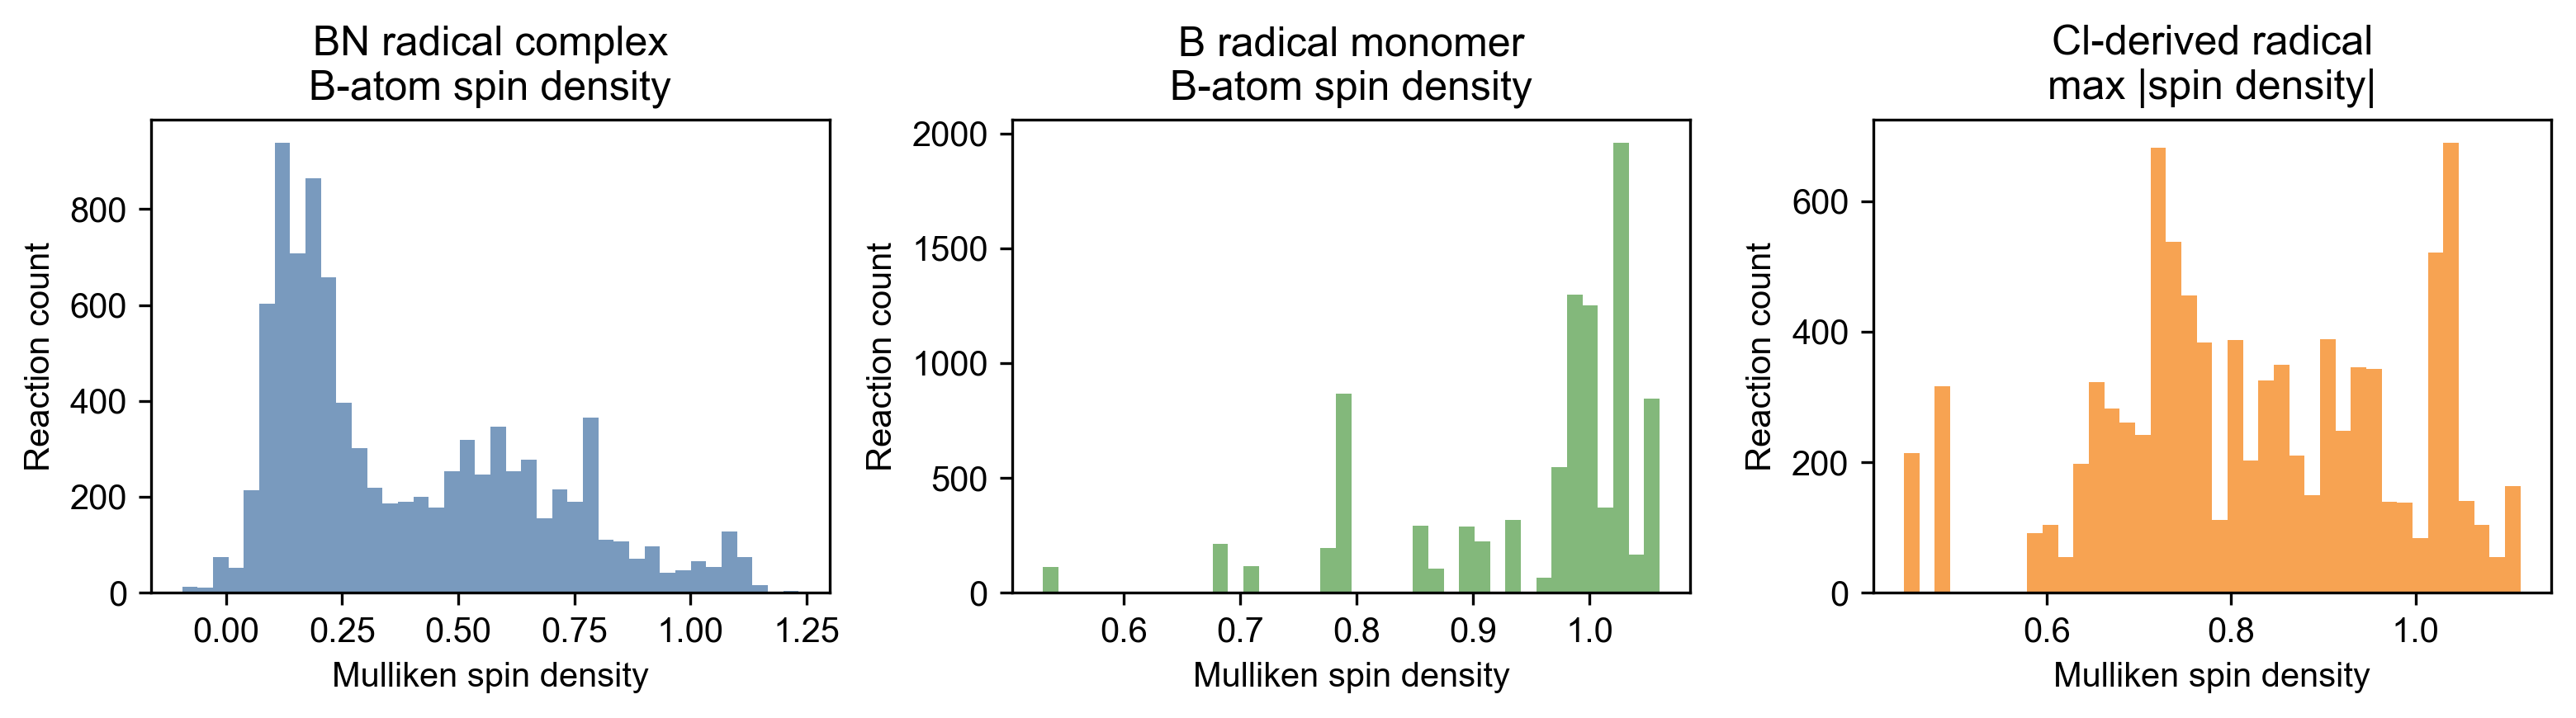

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantSpinDensity_Distribution.png


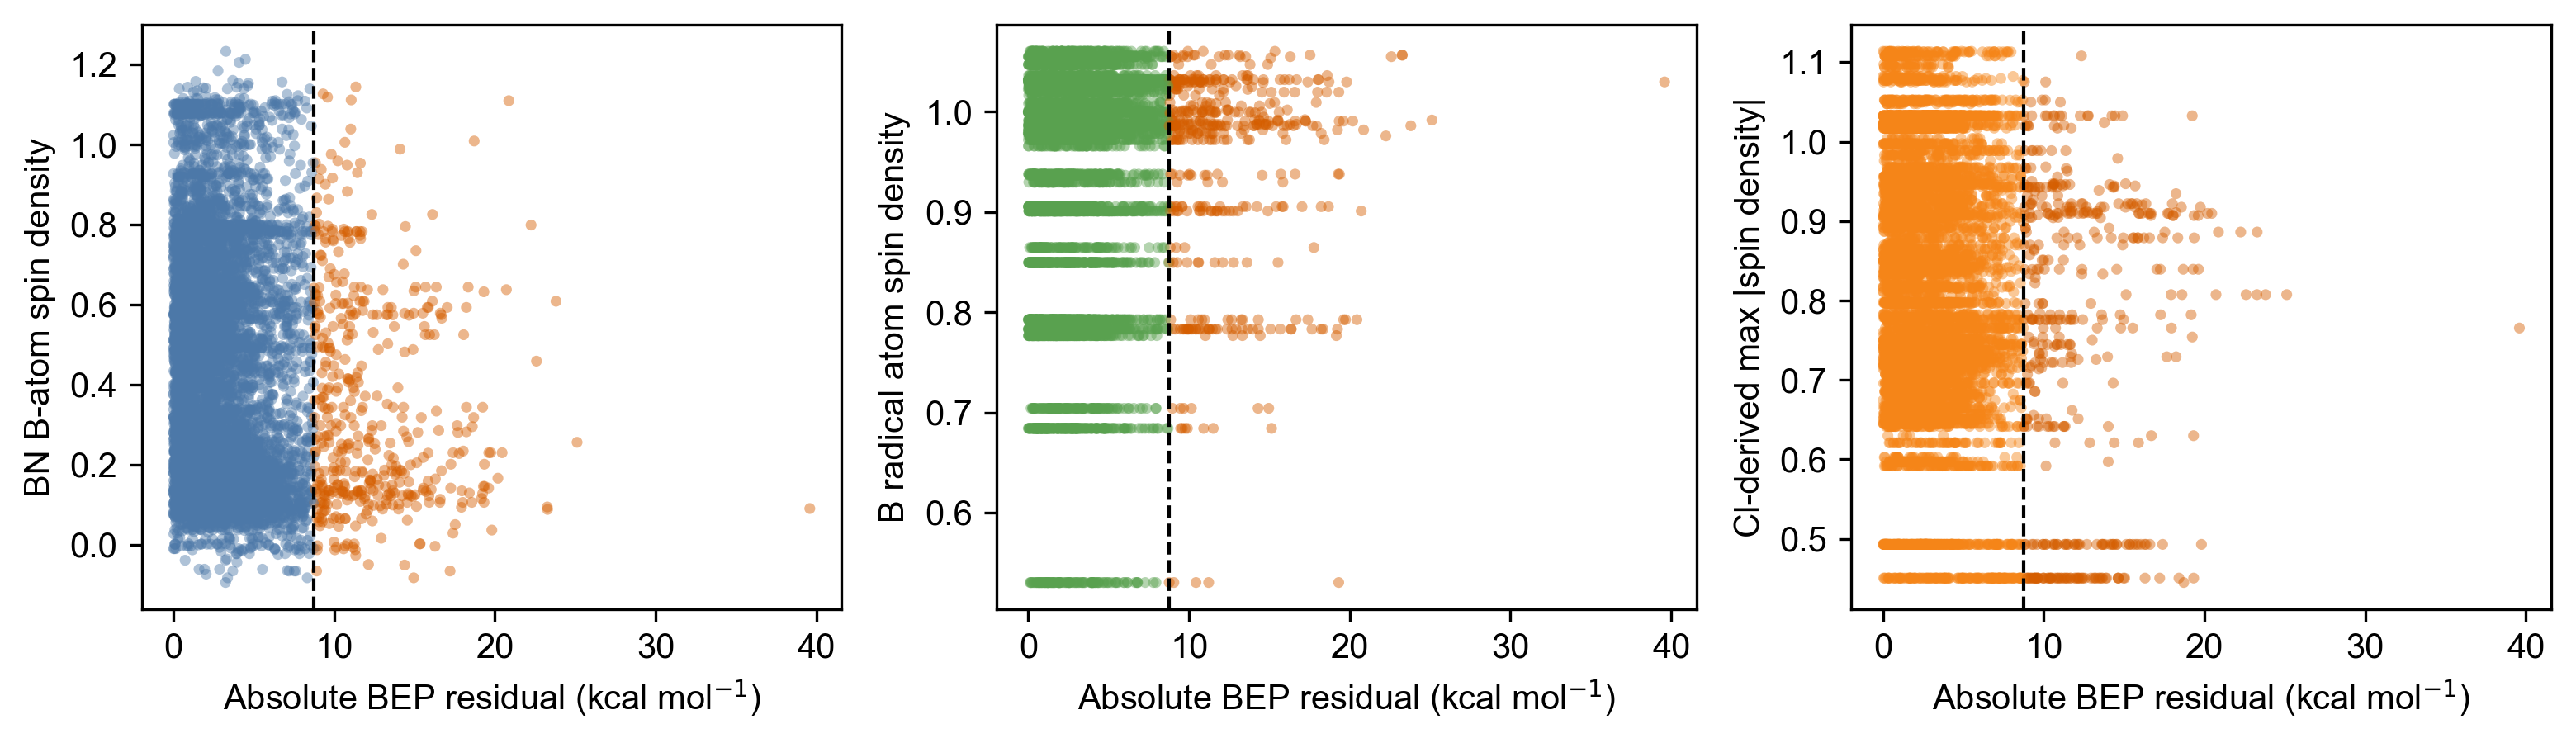

Saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\Revision_ReactantSpinDensity_Outlier_Association.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), dpi=300)
hist_configs = [
    ("bn_b_spin_density", "BN radical complex\nB-atom spin density", "#4C78A8"),
    ("b_atom_spin_density", "B radical monomer\nB-atom spin density", "#59A14F"),
    ("clp_max_abs_spin_density", "Cl-derived radical\nmax |spin density|", "#F58518"),
]
for ax, (col, title, color) in zip(axes, hist_configs):
    values = reactant_spin_analysis[col].dropna()
    ax.hist(values, bins=40, color=color, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel("Mulliken spin density")
    ax.set_ylabel("Reaction count")
fig.tight_layout()
spin_dist_fig = FIGURE_DIR / "Revision_ReactantSpinDensity_Distribution.png"
fig.savefig(spin_dist_fig, bbox_inches="tight")
plt.show()
print(f"Saved: {spin_dist_fig}")

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.1), dpi=300)
scatter_configs = [
    ("bn_b_spin_density", "BN B-atom spin density", "#4C78A8"),
    ("b_atom_spin_density", "B radical atom spin density", "#59A14F"),
    ("clp_max_abs_spin_density", "Cl-derived max |spin density|", "#F58518"),
]
for ax, (col, label, color) in zip(axes, scatter_configs):
    plot_df = reactant_spin_analysis[["bep_abs_residual(kcal/mol)", "bep_outlier_2sigma", col]].dropna()
    point_colors = np.where(plot_df["bep_outlier_2sigma"], "#D55E00", color)
    ax.scatter(
        plot_df["bep_abs_residual(kcal/mol)"],
        plot_df[col],
        s=10,
        c=point_colors,
        alpha=0.45,
        edgecolor="none",
    )
    ax.axvline(bep_outlier_cutoff, color="black", lw=1, ls="--")
    ax.set_xlabel(r"Absolute BEP residual (kcal mol$^{-1}$)")
    ax.set_ylabel(label)
fig.tight_layout()
spin_assoc_fig = FIGURE_DIR / "Revision_ReactantSpinDensity_Outlier_Association.png"
fig.savefig(spin_assoc_fig, bbox_inches="tight")
plt.show()
print(f"Saved: {spin_assoc_fig}")

## 9. Reactant Spin-Density Readout

The key diagnostic for the reaction-specific radical reactant is `bn_b_spin_density`, because the descriptor pipeline uses the Mulliken spin density on the B atom in `B_N_r`.
The component-level summaries above additionally check whether particular boryl radicals, Lewis-base adducts, or chloride-derived radicals are enriched in outliers.

In [20]:
reactant_readout = {
    "n_reactions": len(reactant_spin_analysis),
    "bn_log_coverage": reactant_spin_analysis["bn_log_found"].mean(),
    "b_log_coverage": reactant_spin_analysis["b_log_found"].mean(),
    "clp_log_coverage": reactant_spin_analysis["clp_log_found"].mean(),
    "bn_b_spin_density_median": reactant_spin_analysis["bn_b_spin_density"].median(),
    "bn_b_spin_density_p95": reactant_spin_analysis["bn_b_spin_density"].quantile(0.95),
    "bn_b_spin_density_outlier_median": reactant_spin_analysis.loc[
        reactant_spin_analysis["bep_outlier_2sigma"], "bn_b_spin_density"
    ].median(),
    "bn_b_spin_density_non_outlier_median": reactant_spin_analysis.loc[
        ~reactant_spin_analysis["bep_outlier_2sigma"], "bn_b_spin_density"
    ].median(),
    "bn_b_spin_density_spearman_abs_residual": reactant_spin_analysis[[
        "bep_abs_residual(kcal/mol)", "bn_b_spin_density"
    ]].corr(method="spearman").iloc[0, 1],
    "b_atom_spin_density_spearman_abs_residual": reactant_spin_analysis[[
        "bep_abs_residual(kcal/mol)", "b_atom_spin_density"
    ]].corr(method="spearman").iloc[0, 1],
    "clp_max_abs_spin_density_spearman_abs_residual": reactant_spin_analysis[[
        "bep_abs_residual(kcal/mol)", "clp_max_abs_spin_density"
    ]].corr(method="spearman").iloc[0, 1],
}

for key, value in reactant_readout.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6g}")
    else:
        print(f"{key}: {value}")

n_reactions: 9237
bn_log_coverage: 1
b_log_coverage: 1
clp_log_coverage: 1
bn_b_spin_density_median: 0.280586
bn_b_spin_density_p95: 0.926977
bn_b_spin_density_outlier_median: 0.271471
bn_b_spin_density_non_outlier_median: 0.28096
bn_b_spin_density_spearman_abs_residual: -0.134669
b_atom_spin_density_spearman_abs_residual: 0.0465881
clp_max_abs_spin_density_spearman_abs_residual: -0.0720548
